In [1]:
from pathlib import Path

In [2]:
modern_text = Path("ctl-modernist-fiction/clean00001261.txt").read_text(encoding="utf-8")

In [3]:
len(modern_text)

447440

In [4]:
print(modern_text[:500])

This etext was prepared from the 1896 Fredericke Warne & Co. edition by David Price, email ccx074@coventry.ac.uk A LADY OF QUALITY Being a most curious, hitherto unknown history, as related by Mr. Isaac Bickerstaff but not presented to the World of Fashion through the pages of The Tatler, and now for the first time written down by Francis Hodgson Burnett Were Nature just to Man from his first hour, he need not ask for Mercy; then 'tis for us--the toys of Nature--to be both just and merciful, for


In [5]:
nonmodern_text = Path("1895-1926-ctl-american-non-modernist/clean00001142.txt").read_text(encoding="utf-8")

In [6]:
len(nonmodern_text)

178285

In [7]:
import nltk

In [8]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to D:\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [9]:
from nltk.tokenize import word_tokenize

In [10]:
modern_tokens = word_tokenize(modern_text)

In [11]:
len(modern_tokens)

99884

In [12]:
modern_tokens[:30]

['This',
 'etext',
 'was',
 'prepared',
 'from',
 'the',
 '1896',
 'Fredericke',
 'Warne',
 '&',
 'Co.',
 'edition',
 'by',
 'David',
 'Price',
 ',',
 'email',
 'ccx074',
 '@',
 'coventry.ac.uk',
 'A',
 'LADY',
 'OF',
 'QUALITY',
 'Being',
 'a',
 'most',
 'curious',
 ',',
 'hitherto']

In [13]:
nonmodern_tokens = word_tokenize(nonmodern_text)

In [14]:
len(nonmodern_tokens)

38962

In [15]:
# Clean: keep text starting from Chapter I
modern_start = modern_text.find("CHAPTER I")
nonmodern_start = nonmodern_text.find("CHAPTER I")

modern_text_clean = modern_text[modern_start:]
nonmodern_text_clean = nonmodern_text[nonmodern_start:]

In [16]:
modern_tokens = word_tokenize(modern_text_clean)
nonmodern_tokens = word_tokenize(nonmodern_text_clean)

In [17]:
modern_tokens[:30]

['CHAPTER',
 'I',
 '--',
 'The',
 'twenty-fourth',
 'day',
 'of',
 'November',
 '1690',
 'On',
 'a',
 'wintry',
 'morning',
 'at',
 'the',
 'close',
 'of',
 '1690',
 ',',
 'the',
 'sun',
 'shining',
 'faint',
 'and',
 'red',
 'through',
 'a',
 'light',
 'fog',
 ',']

In [18]:
nonmodern_tokens[:30]

['CHAPTER',
 'I',
 ':',
 'CORSICA',
 'TO',
 'BRIENNE',
 '1769-1779',
 'Napoleon',
 "'s",
 'father',
 ',',
 'Charles',
 'Bonaparte',
 ',',
 'was',
 'the',
 'honored',
 'progenitor',
 'of',
 'thirteen',
 'children',
 ',',
 'of',
 'whom',
 'the',
 'man',
 'who',
 'subsequently',
 'became',
 'the']

In [19]:
modern_tokens = [word.lower() for word in modern_tokens]
nonmodern_tokens = [word.lower() for word in nonmodern_tokens]

In [20]:
modern_words = [word for word in modern_tokens if word.isalpha()]
nonmodern_words = [word for word in nonmodern_tokens if word.isalpha()]

In [21]:
nltk.download("stopwords")

from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

[nltk_data] Downloading package stopwords to D:\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [22]:
modern_words = [
    word
    for word in modern_words
    if word not in stop_words
]

nonmodern_words = [
    word
    for word in nonmodern_words
    if word not in stop_words
]

In [23]:
print(len(modern_words))
print(len(nonmodern_words))

37783
14630


In [24]:
modern_words[:30]

['chapter',
 'day',
 'november',
 'wintry',
 'morning',
 'close',
 'sun',
 'shining',
 'faint',
 'red',
 'light',
 'fog',
 'great',
 'noise',
 'baying',
 'dogs',
 'loud',
 'voices',
 'trampling',
 'horses',
 'wildairs',
 'hall',
 'sir',
 'jeoffry',
 'go',
 'forth',
 'man',
 'choleric',
 'temper',
 'big']

Removing Stopwords: 
Common English function words such as "the," "and," and "of" are removed before the stylistic analysis. Since these words mainly express grammatical structure rather than literary content, removing them allows the analysis to focus more directly on repeated content words that may contribute to literary style.

In [25]:
from nltk import FreqDist

modern_fdist = FreqDist(modern_words)
nonmodern_fdist = FreqDist(nonmodern_words)

modern_fdist.most_common(20)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147)]

In [26]:
nonmodern_fdist.most_common(20)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48)]

In [27]:
print("Top 30 words after removing stopwords")

modern_fdist.most_common(30)

Top 30 words after removing stopwords


[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147),
 ('thing', 146),
 ('seemed', 144),
 ('hand', 137),
 ('little', 136),
 ('beauty', 136),
 ('might', 135),
 ('come', 128),
 ('sister', 128),
 ('even', 127),
 ('back', 119)]

In [28]:
nonmodern_fdist.most_common(30)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48),
 ('shall', 47),
 ('good', 46),
 ('france', 46),
 ('new', 46),
 ('made', 45),
 ('get', 45),
 ('must', 45),
 ('first', 44),
 ('french', 43),
 ('make', 43)]

After removing stopwords, the most frequent words become more meaningful for stylistic analysis. Rather than grammatical function words, the analysis now highlights repeated content words, making it easier to identify recurring themes, objects, characters, and images.

In [29]:
len(modern_words), len(nonmodern_words)

(37783, 14630)

In [30]:
modern_words[:30]

['chapter',
 'day',
 'november',
 'wintry',
 'morning',
 'close',
 'sun',
 'shining',
 'faint',
 'red',
 'light',
 'fog',
 'great',
 'noise',
 'baying',
 'dogs',
 'loud',
 'voices',
 'trampling',
 'horses',
 'wildairs',
 'hall',
 'sir',
 'jeoffry',
 'go',
 'forth',
 'man',
 'choleric',
 'temper',
 'big']

In [31]:
nonmodern_words[:30]

['chapter',
 'corsica',
 'brienne',
 'napoleon',
 'father',
 'charles',
 'bonaparte',
 'honored',
 'progenitor',
 'thirteen',
 'children',
 'man',
 'subsequently',
 'became',
 'emperor',
 'french',
 'curious',
 'provision',
 'fate',
 'second',
 'infant',
 'napoleon',
 'followed',
 'rather',
 'led',
 'procession',
 'foreign',
 'nature',
 'man',
 'many']

In [32]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        
        positions[word].append(index)
    
    return positions

In [33]:
modern_positions = get_word_positions(modern_words)
nonmodern_positions = get_word_positions(nonmodern_words)

In [34]:
modern_positions["horse"][:20]

[126,
 317,
 378,
 439,
 1408,
 1968,
 2012,
 2056,
 2145,
 2166,
 2192,
 2933,
 2936,
 2942,
 2945,
 2947,
 2965,
 3063,
 3084,
 3257]

In [35]:
modern_positions["child"][:20]

[205,
 482,
 504,
 542,
 557,
 837,
 877,
 879,
 900,
 1025,
 1118,
 1331,
 1365,
 1421,
 1486,
 1520,
 1596,
 2293,
 2427,
 2828]

In [36]:
def repetition_distances(position_list):
    distances = []

    for i in range(len(position_list) - 1):
        distance = position_list[i + 1] - position_list[i]
        distances.append(distance)

    return distances

In [37]:
repetition_distances([3, 10, 15, 30])

[7, 5, 15]

In [38]:
horse_distances = repetition_distances(modern_positions["horse"])

horse_distances[:30]

[191,
 61,
 61,
 969,
 560,
 44,
 44,
 89,
 21,
 26,
 741,
 3,
 6,
 3,
 2,
 18,
 98,
 21,
 173,
 231,
 488,
 4294,
 2604,
 626,
 4124,
 19,
 133,
 86,
 4602,
 466]

In [39]:
child_distances = repetition_distances(modern_positions["child"])

child_distances[:30]

[277,
 22,
 38,
 15,
 280,
 40,
 2,
 21,
 125,
 93,
 213,
 34,
 56,
 65,
 34,
 76,
 697,
 134,
 401,
 293,
 116,
 126,
 58,
 187,
 53,
 321,
 146,
 3832,
 75,
 1085]

In [40]:
def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [41]:
average_distance([3, 10, 15, 30])

9.0

In [42]:
average_distance([3, 10, 15, 30])

9.0

In [43]:
average_distance(modern_positions["child"])

498.3066666666667

In [44]:
import statistics

def repetition_summary(word, positions):
    if word not in positions:
        print(word, "does not appear in this text.")
        return
    
    pos = positions[word]
    distances = repetition_distances(pos)
    avg_dist = average_distance(pos)
    
    if len(distances) == 0:
        median_dist = None
    else:
        median_dist = statistics.median(distances)
    
    print("Word:", word)
    print("Number of occurrences:", len(pos))
    print("First 30 positions:", pos[:30])
    print("First 30 repetition distances:", distances[:30])
    print("Average repetition distance:", avg_dist)
    print("Median repetition distance:", median_dist)

In [45]:
repetition_summary("horse", modern_positions)

Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95


In [46]:
repetition_summary("child", modern_positions)

Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 280, 40, 2, 21, 125, 93, 213, 34, 56, 65, 34, 76, 697, 134, 401, 293, 116, 126, 58, 187, 53, 321, 146, 3832, 75, 1085]
Average repetition distance: 498.3066666666667
Median repetition distance: 126


In [47]:
"horse" in nonmodern_positions, "child" in nonmodern_positions

(True, True)

In [48]:
print("Modern text:")
repetition_summary("horse", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("horse", nonmodern_positions)

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [5225]
First 30 repetition distances: []
Average repetition distance: None
Median repetition distance: None


In [49]:
print("Modern text:")
repetition_summary("child", modern_positions)

print()

print("Nonmodern text:")
repetition_summary("child", nonmodern_positions)

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 280, 40, 2, 21, 125, 93, 213, 34, 56, 65, 34, 76, 697, 134, 401, 293, 116, 126, 58, 187, 53, 321, 146, 3832, 75, 1085]
Average repetition distance: 498.3066666666667
Median repetition distance: 126

Nonmodern text:
Word: child
Number of occurrences: 6
First 30 positions: [44, 199, 357, 981, 1062, 7107]
First 30 repetition distances: [155, 158, 624, 81, 6045]
Average repetition distance: 1412.6
Median repetition distance: 158


In [50]:
modern_fdist.most_common(80)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147),
 ('thing', 146),
 ('seemed', 144),
 ('hand', 137),
 ('little', 136),
 ('beauty', 136),
 ('might', 135),
 ('come', 128),
 ('sister', 128),
 ('even', 127),
 ('back', 119),
 ('look', 117),
 ('knew', 117),
 ('never', 117),
 ('must', 115),
 ('came', 113),
 ('time', 109),
 ('young', 108),
 ('stood', 107),
 ('see', 104),
 ('god', 102),
 ('life', 100),
 ('know', 99),
 ('went', 98),
 ('indeed', 97),
 ('way', 97),
 ('dunstanwolde', 97),
 ('lord', 95),
 ('thought', 93),
 ('well', 92),
 ('cried', 92),
 ('first', 91),
 ('john', 91),
 ('saw', 90),
 ('day', 89),
 ('looked', 88),
 ('night', 85),
 ('ever', 85),
 ('away', 82),
 ('strange', 82),
 ('head', 81),
 ('lay', 80),
 ('je

In [51]:
words_to_compare = ["horse", "child", "woman", "man", "house", "room", "eyes", "hand", "day", "time"]

In [52]:
for word in words_to_compare:
    print("====================")
    print("WORD:", word)
    print()
    
    print("Modern text:")
    repetition_summary(word, modern_positions)
    print()
    
    print("Nonmodern text:")
    repetition_summary(word, nonmodern_positions)
    print()

WORD: horse

Modern text:
Word: horse
Number of occurrences: 48
First 30 positions: [126, 317, 378, 439, 1408, 1968, 2012, 2056, 2145, 2166, 2192, 2933, 2936, 2942, 2945, 2947, 2965, 3063, 3084, 3257, 3488, 3976, 8270, 10874, 11500, 15624, 15643, 15776, 15862, 20464]
First 30 repetition distances: [191, 61, 61, 969, 560, 44, 44, 89, 21, 26, 741, 3, 6, 3, 2, 18, 98, 21, 173, 231, 488, 4294, 2604, 626, 4124, 19, 133, 86, 4602, 466]
Average repetition distance: 585.5531914893617
Median repetition distance: 95

Nonmodern text:
Word: horse
Number of occurrences: 1
First 30 positions: [5225]
First 30 repetition distances: []
Average repetition distance: None
Median repetition distance: None

WORD: child

Modern text:
Word: child
Number of occurrences: 76
First 30 positions: [205, 482, 504, 542, 557, 837, 877, 879, 900, 1025, 1118, 1331, 1365, 1421, 1486, 1520, 1596, 2293, 2427, 2828, 3121, 3237, 3363, 3421, 3608, 3661, 3982, 4128, 7960, 8035]
First 30 repetition distances: [277, 22, 38, 15, 

In [53]:
def normalized_frequency(word, words):
    count = words.count(word)
    return count / len(words) * 1000

In [54]:
normalized_frequency("horse", modern_words)

1.2704126194320196

In [55]:
normalized_frequency("horse", nonmodern_words)

0.06835269993164729

In [56]:
def compare_word(word):
    print("Word:", word)
    print()
    
    print("Modern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, modern_words))
    
    if word in modern_positions:
        print("Average repetition distance:", average_distance(modern_positions[word]))
    else:
        print("Average repetition distance: None")
    
    print()
    
    print("Nonmodern text:")
    print("Frequency per 1000 words:", normalized_frequency(word, nonmodern_words))
    
    if word in nonmodern_positions:
        print("Average repetition distance:", average_distance(nonmodern_positions[word]))
    else:
        print("Average repetition distance: None")

In [57]:
def all_repetition_distances(positions):
    all_distances = []
    
    for word in positions:
        distances = repetition_distances(positions[word])
        all_distances.extend(distances)
    
    return all_distances

In [58]:
def text_style_features(words, positions):
    total_words = len(words)
    vocabulary_size = len(set(words))
    type_token_ratio = vocabulary_size / total_words
    
    repeated_words = []
    for word in positions:
        if len(positions[word]) > 1:
            repeated_words.append(word)
    
    repeated_word_ratio = len(repeated_words) / vocabulary_size
    
    distances = all_repetition_distances(positions)
    
    if len(distances) == 0:
        average_rep_distance = None
        median_rep_distance = None
    else:
        average_rep_distance = sum(distances) / len(distances)
        median_rep_distance = statistics.median(distances)
    
    print("Total words:", total_words)
    print("Vocabulary size:", vocabulary_size)
    print("Type-token ratio:", type_token_ratio)
    print("Repeated word count:", len(repeated_words))
    print("Repeated word ratio:", repeated_word_ratio)
    print("Average repetition distance:", average_rep_distance)
    print("Median repetition distance:", median_rep_distance)

In [59]:
compare_word("horse")

Word: horse

Modern text:
Frequency per 1000 words: 1.2704126194320196
Average repetition distance: 585.5531914893617

Nonmodern text:
Frequency per 1000 words: 0.06835269993164729
Average repetition distance: None


In [60]:
print("Modern text style features")
print("==========================")
text_style_features(modern_words, modern_positions)

Modern text style features
Total words: 37783
Vocabulary size: 5983
Type-token ratio: 0.15835163962628696
Repeated word count: 3297
Repeated word ratio: 0.5510613404646498
Average repetition distance: 2022.4701257861636
Median repetition distance: 478.0


In [61]:
print("Nonmodern text style features")
print("=============================")
text_style_features(nonmodern_words, nonmodern_positions)

Nonmodern text style features
Total words: 14630
Vocabulary size: 4537
Type-token ratio: 0.3101161995898838
Repeated word count: 2011
Repeated word ratio: 0.4432444346484461
Average repetition distance: 1336.7358565342317
Median repetition distance: 426


In [62]:
compare_word("child")

Word: child

Modern text:
Frequency per 1000 words: 2.011486647434031
Average repetition distance: 498.3066666666667

Nonmodern text:
Frequency per 1000 words: 0.4101161995898838
Average repetition distance: 1412.6


In [63]:
compare_word("woman")

Word: woman

Modern text:
Frequency per 1000 words: 6.060926871873594
Average repetition distance: 164.18421052631578

Nonmodern text:
Frequency per 1000 words: 0.9569377990430622
Average repetition distance: 1074.3846153846155


In [64]:
print(
    f'{"Word":<10} {"Modern Freq":>12} {"Nonmodern Freq":>15} {"Modern Dist":>15} {"Nonmodern Dist":>18}'
)

print("-" * 75)

for word in words_to_compare:

    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    print(
        f"{word:<10} {modern_freq:>12.2f} {nonmodern_freq:>15.2f} {str(round(modern_dist,2)) if modern_dist else 'None':>15} {str(round(nonmodern_dist,2)) if nonmodern_dist else 'None':>18}"
    )

Word        Modern Freq  Nonmodern Freq     Modern Dist     Nonmodern Dist
---------------------------------------------------------------------------
horse              1.27            0.07          585.55               None
child              2.01            0.41          498.31             1412.6
woman              6.06            0.96          164.18            1074.38
man                6.33            4.24          158.33             235.98
house              1.93            0.62          486.29            1664.62
room               1.43            0.62          695.89            1500.25
eyes               5.98            0.41          165.95             2211.8
hand               3.63            1.23          273.74             764.18
day                2.36            2.46          427.16             411.83
time               2.88            4.37          324.02              224.6


In [65]:
from pathlib import Path

modern_folder = Path("ctl-modernist-fiction")
nonmodern_folder = Path("1895-1926-ctl-american-non-modernist")

modern_files = list(modern_folder.glob("*.txt"))
nonmodern_files = list(nonmodern_folder.glob("*.txt"))

len(modern_files), len(nonmodern_files)

(41, 984)

In [66]:
modern_files_sample = modern_files[:10]
nonmodern_files_sample = nonmodern_files[:10]

modern_files_sample, nonmodern_files_sample

([WindowsPath('ctl-modernist-fiction/clean00001261.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001690.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001828.txt'),
  WindowsPath('ctl-modernist-fiction/clean00001884.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002304.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002437.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002725.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002948.txt'),
  WindowsPath('ctl-modernist-fiction/clean00002949.txt'),
  WindowsPath('ctl-modernist-fiction/clean00003082.txt')],
 [WindowsPath('1895-1926-ctl-american-non-modernist/clean00001142.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001156.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001160.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001161.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/clean00001162.txt'),
  WindowsPath('1895-1926-ctl-american-non-modernist/cl

In [67]:
from nltk.tokenize import word_tokenize

def read_and_tokenize(file_path):
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    
    start = text.find("CHAPTER I")
    if start != -1:
        text = text[start:]
    
    tokens = word_tokenize(text)
    words = [word.lower() for word in tokens if word.isalpha()]
    
    return words

In [68]:
def get_word_positions(words):
    positions = {}
    
    for index, word in enumerate(words):
        if word not in positions:
            positions[word] = []
        positions[word].append(index)
    
    return positions


def repetition_distances(position_list):
    distances = []
    
    for i in range(len(position_list) - 1):
        distances.append(position_list[i + 1] - position_list[i])
    
    return distances


def average_distance(position_list):
    distances = repetition_distances(position_list)
    
    if len(distances) == 0:
        return None
    
    return sum(distances) / len(distances)

In [69]:
def text_repetition_features(file_path, label):
    words = read_and_tokenize(file_path)
    positions = get_word_positions(words)
    
    repeated_words = [word for word in positions if len(positions[word]) >= 2]
    
    repetition_rate = len(repeated_words) / len(set(words))
    
    all_distances = []
    for word in repeated_words:
        all_distances.extend(repetition_distances(positions[word]))
    
    if len(all_distances) > 0:
        avg_repetition_distance = sum(all_distances) / len(all_distances)
    else:
        avg_repetition_distance = None
    
    return {
        "file": file_path.name,
        "label": label,
        "total_words": len(words),
        "unique_words": len(set(words)),
        "repeated_words": len(repeated_words),
        "repetition_rate": repetition_rate,
        "avg_repetition_distance": avg_repetition_distance
    }

In [70]:
import pandas as pd

rows = []

for file in modern_files_sample:
    rows.append(text_repetition_features(file, "modernist"))

for file in nonmodern_files_sample:
    rows.append(text_repetition_features(file, "nonmodernist"))

df = pd.DataFrame(rows)

In [71]:
df.groupby("label")[[
    "total_words",
    "unique_words",
    "repeated_words",
    "repetition_rate",
    "avg_repetition_distance"
]].mean()

,total_words,unique_words,repeated_words,repetition_rate,avg_repetition_distance
label,,,,,
modernist,83132.0,7077.0,3751.6,0.51114,2196.201498
nonmodernist,67055.1,6467.1,3357.7,0.51197,1940.227861


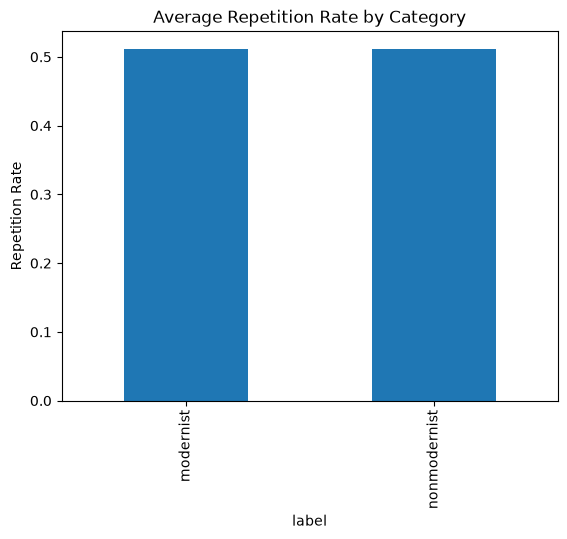

In [72]:
import matplotlib.pyplot as plt

df.groupby("label")["repetition_rate"].mean().plot(kind="bar")

plt.title("Average Repetition Rate by Category")
plt.ylabel("Repetition Rate")
plt.show()

In [73]:
from nltk import ConditionalFreqDist

text_word_pairs = []

for word in modern_words:
    text_word_pairs.append(("modern", word))

for word in nonmodern_words:
    text_word_pairs.append(("nonmodern", word))

cfd = ConditionalFreqDist(text_word_pairs)

In [74]:
cfd["modern"].most_common(20)

[('said', 508),
 ('would', 394),
 ('one', 299),
 ('anne', 297),
 ('upon', 275),
 ('could', 241),
 ('man', 239),
 ('great', 235),
 ('woman', 229),
 ('eyes', 226),
 ('like', 186),
 ('lady', 178),
 ('clorinda', 174),
 ('mistress', 164),
 ('love', 159),
 ('made', 154),
 ('sir', 153),
 ('poor', 151),
 ('face', 148),
 ('though', 147)]

In [75]:
cfd["nonmodern"].most_common(20)

[('said', 257),
 ('napoleon', 213),
 ('bonaparte', 181),
 ('one', 115),
 ('would', 80),
 ('well', 80),
 ('emperor', 74),
 ('fouche', 74),
 ('paris', 73),
 ('joseph', 69),
 ('could', 65),
 ('time', 64),
 ('man', 62),
 ('upon', 59),
 ('go', 53),
 ('army', 51),
 ('returned', 50),
 ('like', 48),
 ('know', 48),
 ('people', 48)]

Here I use ConditionalFreqDist to compare word frequency under two conditions: modern and nonmodern. 
This connects to the NLTK section on conditional frequency distributions, where a condition groups observations.
In my case, the condition is the text category, and the event is each word.

In [76]:
candidate_words = []

for word in modern_fdist:
    if modern_fdist[word] >= 20 and nonmodern_fdist[word] >= 1:
        candidate_words.append(word)

candidate_words = sorted(candidate_words)

len(candidate_words)

316

In [77]:
def word_feature_row(word):
    modern_freq = normalized_frequency(word, modern_words)
    nonmodern_freq = normalized_frequency(word, nonmodern_words)

    if word in modern_positions:
        modern_dist = average_distance(modern_positions[word])
    else:
        modern_dist = None

    if word in nonmodern_positions:
        nonmodern_dist = average_distance(nonmodern_positions[word])
    else:
        nonmodern_dist = None

    return [word, modern_freq, nonmodern_freq, modern_dist, nonmodern_dist]

In [78]:
feature_rows = []

for word in candidate_words:
    feature_rows.append(word_feature_row(word))

feature_rows[:10]

[['air', 1.0057433237170155, 0.27341079972658916, 956.1351351351351, 2138.0],
 ['almost', 1.6938834925760262, 0.06835269993164729, 555.2063492063492, None],
 ['alone', 1.164544901146018, 0.34176349965823655, 835.6976744186046, 3057.75],
 ['also', 0.9263425350025143, 0.6151742993848256, 1030.764705882353, 1567.375],
 ['always',
  1.29687954900352,
  1.3670539986329462,
  726.7708333333334,
  738.6842105263158],
 ['among', 1.6409496334330256, 0.13670539986329458, 576.7540983606557, 8848.0],
 ['another',
  1.1116110420030172,
  1.3670539986329462,
  907.8780487804878,
  690.421052631579],
 ['answer',
  0.6352063097160098,
  0.2050580997949419,
  1617.8260869565217,
  6220.0],
 ['arm', 0.6616732392875103, 0.13670539986329458, 1443.0, 986.0],
 ['arms', 0.8734086758595135, 0.4784688995215311, 1129.15625, 1942.0]]

In [79]:
import pandas as pd

features_df = pd.DataFrame(
    feature_rows,
    columns=[
        "word",
        "modern_freq_per_1000",
        "nonmodern_freq_per_1000",
        "modern_avg_distance",
        "nonmodern_avg_distance"
    ]
)

features_df.head()

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance
0,air,1.005743,0.273411,956.135135,2138.000000
1,almost,1.693883,0.068353,555.206349,NaN
2,alone,1.164545,0.341763,835.697674,3057.750000
3,also,0.926343,0.615174,1030.764706,1567.375000
4,always,1.296880,1.367054,726.770833,738.684211


In [80]:
features_df["frequency_difference"] = (
    features_df["modern_freq_per_1000"] 
    - features_df["nonmodern_freq_per_1000"]
)

features_df.sort_values("frequency_difference", ascending=False).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
65,eyes,5.981526,0.410116,165.946667,2211.800000,5.571410
303,woman,6.060927,0.956938,164.184211,1074.384615,5.103989
310,would,10.427970,5.468216,93.893130,173.683544,4.959754
133,lady,4.711113,0.136705,211.480226,503.000000,4.574408
99,great,6.219728,2.460697,161.059829,400.257143,3.759031
241,sir,4.049440,0.546822,231.197368,1033.142857,3.502619
16,beauty,3.599502,0.136705,253.140741,3501.000000,3.462797
230,seemed,3.811238,0.478469,258.237762,2004.000000,3.332769
207,poor,3.996506,0.683527,249.433333,1352.111111,3.312979
290,upon,7.278406,4.032809,136.777372,242.603448,3.245596


This table helps me identify words that appear much more often in the modern text than in the nonmodern text.
However, frequency alone is not enough for my project, because I am interested in repetition as a pattern.
Therefore, I also compare average repetition distance.
A smaller average distance means that repeated words appear closer together.

In [81]:
modern_repetition_candidates = features_df[
    (features_df["modern_freq_per_1000"] > features_df["nonmodern_freq_per_1000"]) &
    (features_df["modern_avg_distance"] < features_df["nonmodern_avg_distance"])
]

modern_repetition_candidates.sort_values(
    "frequency_difference", 
    ascending=False
).head(20)

,word,modern_freq_per_1000,nonmodern_freq_per_1000,modern_avg_distance,nonmodern_avg_distance,frequency_difference
65,eyes,5.981526,0.410116,165.946667,2211.800000,5.571410
303,woman,6.060927,0.956938,164.184211,1074.384615,5.103989
310,would,10.427970,5.468216,93.893130,173.683544,4.959754
133,lady,4.711113,0.136705,211.480226,503.000000,4.574408
99,great,6.219728,2.460697,161.059829,400.257143,3.759031
241,sir,4.049440,0.546822,231.197368,1033.142857,3.502619
16,beauty,3.599502,0.136705,253.140741,3501.000000,3.462797
230,seemed,3.811238,0.478469,258.237762,2004.000000,3.332769
207,poor,3.996506,0.683527,249.433333,1352.111111,3.312979
290,upon,7.278406,4.032809,136.777372,242.603448,3.245596


In [82]:
def split_into_chunks(words, chunk_size=1000):
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = words[i:i + chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

In [83]:
modern_chunks = split_into_chunks(modern_words, 1000)
nonmodern_chunks = split_into_chunks(nonmodern_words, 1000)

len(modern_chunks), len(nonmodern_chunks)

(37, 14)

In [84]:
def chunk_repetition_features(chunk):
    freq = FreqDist(chunk)

    repeated_words = [word for word in freq if freq[word] > 1]

    repeated_word_count = len(repeated_words)
    total_repetition_count = sum(freq[word] - 1 for word in repeated_words)
    unique_ratio = len(set(chunk)) / len(chunk)

    return {
        "repeated_word_count": repeated_word_count,
        "total_repetition_count": total_repetition_count,
        "unique_ratio": unique_ratio
    }

In [85]:
chunk_repetition_features(modern_chunks[0])

{'repeated_word_count': 181,
 'total_repetition_count': 390,
 'unique_ratio': 0.61}

In [86]:
rows = []

for chunk in modern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "modern"
    rows.append(features)

for chunk in nonmodern_chunks:
    features = chunk_repetition_features(chunk)
    features["label"] = "nonmodern"
    rows.append(features)

chunk_df = pd.DataFrame(rows)
chunk_df.head()

,repeated_word_count,total_repetition_count,unique_ratio,label
0,181,390,0.610,modern
1,180,373,0.627,modern
2,171,391,0.609,modern
3,166,329,0.671,modern
4,160,369,0.631,modern


In [87]:
chunk_df.groupby("label").mean()

,repeated_word_count,total_repetition_count,unique_ratio
label,,,
modern,174.351351,394.108108,0.605892
nonmodern,155.214286,340.428571,0.659571


This is my first classifier-style dataset. 
Each row represents a 1000-word section of a text.
Instead of classifying an entire book at once, I treat each chunk as a sample.
The features measure repetition: how many words repeat, how many repeated uses appear, and how diverse the vocabulary is.

<Axes: xlabel='label'>

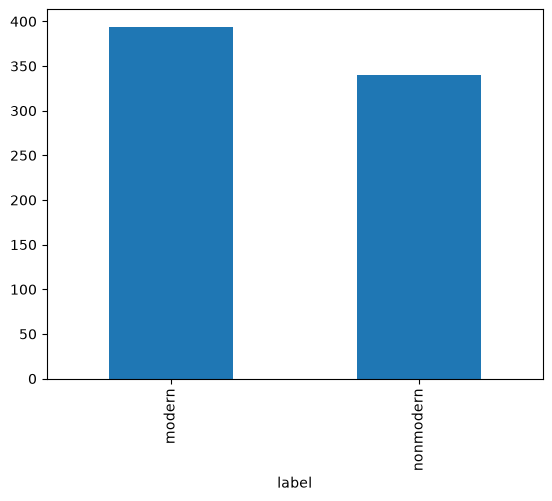

In [88]:
chunk_df.groupby("label")["total_repetition_count"].mean().plot(kind="bar")

At this stage, I am not claiming that repetition alone can classify modernism.
Instead, I am building measurable repetition features that could later become part of a classifier.
The next step would be to add more modernist and nonmodernist texts, because two texts are not enough to make a reliable classification model.

In [89]:
def word_style_features(word, words, positions):
    result = {}

    result["Word"] = word
    result["Occurrences"] = words.count(word)
    result["Frequency per 1000 words"] = normalized_frequency(word, words)

    if word in positions:
        result["Average repetition distance"] = average_distance(positions[word])
    else:
        result["Average repetition distance"] = None

    return result

In [90]:
word_style_features("child", modern_words, modern_positions)

{'Word': 'child',
 'Occurrences': 76,
 'Frequency per 1000 words': 2.011486647434031,
 'Average repetition distance': 498.3066666666667}

In [91]:
import pandas as pd

In [92]:
interesting_words = [
    "child",
    "woman",
    "man",
    "eyes",
    "hand",
    "house",
    "room",
    "day",
    "time"
]

In [93]:
modern_results = []

for word in interesting_words:
    features = word_style_features(
        word,
        modern_words,
        modern_positions
    )

    modern_results.append(features)

modern_df = pd.DataFrame(modern_results)

modern_df

,Word,Occurrences,Frequency per 1000 words,Average repetition distance
0,child,76,2.011487,498.306667
1,woman,229,6.060927,164.184211
2,man,239,6.325596,158.327731
3,eyes,226,5.981526,165.946667
4,hand,137,3.625969,273.742647
5,house,73,1.932086,486.291667
6,room,54,1.429214,695.886792
7,day,89,2.355557,427.159091
8,time,109,2.884895,324.018519


In [94]:
nonmodern_results = []

for word in interesting_words:
    features = word_style_features(
        word,
        nonmodern_words,
        nonmodern_positions
    )

    nonmodern_results.append(features)

nonmodern_df = pd.DataFrame(nonmodern_results)

nonmodern_df

,Word,Occurrences,Frequency per 1000 words,Average repetition distance
0,child,6,0.410116,1412.600000
1,woman,14,0.956938,1074.384615
2,man,62,4.237867,235.983607
3,eyes,6,0.410116,2211.800000
4,hand,18,1.230349,764.176471
5,house,9,0.615174,1664.625000
6,room,9,0.615174,1500.250000
7,day,36,2.460697,411.828571
8,time,64,4.374573,224.603175


Instead of examining repetition for only one word at a time, I organized several repetition-related measurements into a small style profile.
Each word is represented by three computational features: number of occurrences, normalized frequency, average repetition distance
This moves the project one step closer to representing stylistic patterns rather than isolated repetitions.

Text-Level Repetition Features：
The previous analysis examined repetition features for selected individual words. However, a classifier requires a fixed set of numerical features for every complete text. In this section, I summarize repetition patterns across the entire text so that each literary work can be represented as one row of classifier-ready data.

In [95]:
def collect_all_repetition_distances(positions):
    all_distances = []

    for word, position_list in positions.items():
        if len(position_list) >= 2:
            distances = repetition_distances(position_list)
            all_distances.extend(distances)

    return all_distances

In [96]:
modern_all_distances = collect_all_repetition_distances(modern_positions)

len(modern_all_distances)

31800

In [97]:
modern_all_distances[:30]

[1141,
 1580,
 1332,
 1834,
 1643,
 1747,
 1455,
 2313,
 960,
 1160,
 2157,
 1141,
 1996,
 2206,
 1817,
 1917,
 1933,
 831,
 1779,
 1084,
 1782,
 735,
 1370,
 47,
 6,
 31,
 1108,
 1,
 757,
 37]

In [98]:
nonmodern_all_distances = collect_all_repetition_distances(nonmodern_positions)

len(nonmodern_all_distances)

10093

In [99]:
def short_repetition_ratio(distances, threshold):
    if len(distances) == 0:
        return 0

    short_distances = [
        distance
        for distance in distances
        if distance <= threshold
    ]

    return len(short_distances) / len(distances)

In [100]:
short_repetition_ratio([2, 5, 10, 30, 100], 10)

0.6

In [101]:
def text_repetition_features(words, positions):
    total_words = len(words)
    vocabulary_size = len(positions)

    repeated_words = {
        word: position_list
        for word, position_list in positions.items()
        if len(position_list) >= 2
    }

    repeated_word_types = len(repeated_words)

    all_distances = collect_all_repetition_distances(positions)

    occurrence_counts = [
        len(position_list)
        for position_list in repeated_words.values()
    ]

    if total_words == 0:
        type_token_ratio = 0
    else:
        type_token_ratio = vocabulary_size / total_words

    if vocabulary_size == 0:
        repeated_type_ratio = 0
    else:
        repeated_type_ratio = repeated_word_types / vocabulary_size

    if len(all_distances) == 0:
        mean_repetition_distance = None
        median_repetition_distance = None
    else:
        mean_repetition_distance = statistics.mean(all_distances)
        median_repetition_distance = statistics.median(all_distances)

    if len(occurrence_counts) == 0:
        mean_repeated_word_frequency = 0
        median_repeated_word_frequency = 0
    else:
        mean_repeated_word_frequency = statistics.mean(occurrence_counts)
        median_repeated_word_frequency = statistics.median(occurrence_counts)

    return {
        "Total words": total_words,
        "Vocabulary size": vocabulary_size,
        "Type-token ratio": type_token_ratio,
        "Repeated word types": repeated_word_types,
        "Repeated type ratio": repeated_type_ratio,
        "Mean repeated-word frequency": mean_repeated_word_frequency,
        "Median repeated-word frequency": median_repeated_word_frequency,
        "Mean repetition distance": mean_repetition_distance,
        "Median repetition distance": median_repetition_distance,
        "Repetition distance <= 5": short_repetition_ratio(
            all_distances,
            5
        ),
        "Repetition distance <= 20": short_repetition_ratio(
            all_distances,
            20
        ),
        "Repetition distance <= 100": short_repetition_ratio(
            all_distances,
            100
        )
    }

In [102]:
modern_text_features = text_repetition_features(
    modern_words,
    modern_positions
)

modern_text_features

{'Total words': 37783,
 'Vocabulary size': 5983,
 'Type-token ratio': 0.15835163962628696,
 'Repeated word types': 3297,
 'Repeated type ratio': 0.5510613404646498,
 'Mean repeated-word frequency': 10.64513193812557,
 'Median repeated-word frequency': 4,
 'Mean repetition distance': 2022.4701257861636,
 'Median repetition distance': 478.0,
 'Repetition distance <= 5': 0.028522012578616352,
 'Repetition distance <= 20': 0.08305031446540881,
 'Repetition distance <= 100': 0.24581761006289307}

In [103]:
nonmodern_text_features = text_repetition_features(
    nonmodern_words,
    nonmodern_positions
)

nonmodern_text_features

{'Total words': 14630,
 'Vocabulary size': 4537,
 'Type-token ratio': 0.3101161995898838,
 'Repeated word types': 2011,
 'Repeated type ratio': 0.4432444346484461,
 'Mean repeated-word frequency': 6.018896071606166,
 'Median repeated-word frequency': 3,
 'Mean repetition distance': 1336.7358565342317,
 'Median repetition distance': 426,
 'Repetition distance <= 5': 0.024868720895670268,
 'Repetition distance <= 20': 0.10660854057267413,
 'Repetition distance <= 100': 0.27494302982264934}

In [104]:
text_feature_df = pd.DataFrame([
    {
        "Text": "Modern",
        "Label": 1,
        **modern_text_features
    },
    {
        "Text": "Nonmodern",
        "Label": 0,
        **nonmodern_text_features
    }
])

text_feature_df

,Text,Label,Total words,Vocabulary size,Type-token ratio,Repeated word types,Repeated type ratio,Mean repeated-word frequency,Median repeated-word frequency,Mean repetition distance,Median repetition distance,Repetition distance <= 5,Repetition distance <= 20,Repetition distance <= 100
0,Modern,1,37783,5983,0.158352,3297,0.551061,10.645132,4,2022.470126,478.0,0.028522,0.083050,0.245818
1,Nonmodern,0,14630,4537,0.310116,2011,0.443244,6.018896,3,1336.735857,426.0,0.024869,0.106609,0.274943


In [105]:
comparison_df = text_feature_df.set_index("Text").drop(
    columns="Label"
).transpose()

comparison_df

Text,Modern,Nonmodern
Total words,37783.000000,14630.000000
Vocabulary size,5983.000000,4537.000000
Type-token ratio,0.158352,0.310116
Repeated word types,3297.000000,2011.000000
Repeated type ratio,0.551061,0.443244
Mean repeated-word frequency,10.645132,6.018896
Median repeated-word frequency,4.000000,3.000000
Mean repetition distance,2022.470126,1336.735857
Median repetition distance,478.000000,426.000000
Repetition distance <= 5,0.028522,0.024869


In [106]:
comparison_df.round(4)

Text,Modern,Nonmodern
Total words,37783.0000,14630.0000
Vocabulary size,5983.0000,4537.0000
Type-token ratio,0.1584,0.3101
Repeated word types,3297.0000,2011.0000
Repeated type ratio,0.5511,0.4432
Mean repeated-word frequency,10.6451,6.0189
Median repeated-word frequency,4.0000,3.0000
Mean repetition distance,2022.4701,1336.7359
Median repetition distance,478.0000,426.0000
Repetition distance <= 5,0.0285,0.0249


In [107]:
modern_text_features.keys() == nonmodern_text_features.keys()

True

In [108]:
feature_difference_df = comparison_df.copy()

feature_difference_df["Difference (Modern - Nonmodern)"] = (
    feature_difference_df["Modern"]
    - feature_difference_df["Nonmodern"]
)

feature_difference_df.round(4)

Text,Modern,Nonmodern,Difference (Modern - Nonmodern)
Total words,37783.0000,14630.0000,23153.0000
Vocabulary size,5983.0000,4537.0000,1446.0000
Type-token ratio,0.1584,0.3101,-0.1518
Repeated word types,3297.0000,2011.0000,1286.0000
Repeated type ratio,0.5511,0.4432,0.1078
Mean repeated-word frequency,10.6451,6.0189,4.6262
Median repeated-word frequency,4.0000,3.0000,1.0000
Mean repetition distance,2022.4701,1336.7359,685.7343
Median repetition distance,478.0000,426.0000,52.0000
Repetition distance <= 5,0.0285,0.0249,0.0037


In [109]:
normalized_features = [
    "Type-token ratio",
    "Repeated type ratio",
    "Mean repeated-word frequency",
    "Median repeated-word frequency",
    "Repetition distance <= 5",
    "Repetition distance <= 20",
    "Repetition distance <= 100"
]

comparison_df.loc[normalized_features].round(4)

Text,Modern,Nonmodern
Type-token ratio,0.1584,0.3101
Repeated type ratio,0.5511,0.4432
Mean repeated-word frequency,10.6451,6.0189
Median repeated-word frequency,4.0000,3.0000
Repetition distance <= 5,0.0285,0.0249
Repetition distance <= 20,0.0831,0.1066
Repetition distance <= 100,0.2458,0.2749


Preliminary Results: The two texts show different repetition patterns at the text level. The modern text has a higher repeated-type ratio, meaning that a larger proportion of its vocabulary appears more than once. It also has a higher mean and median repeated-word frequency, suggesting that words which repeat tend to occur more frequently overall in the modern text.
However, the short-distance measurements do not show one simple pattern. The modern text has a slightly higher proportion of repetitions within 5 content-word tokens, while the nonmodern text has higher proportions of repetitions within 20 and 100 tokens. This suggests that the modern text may contain slightly more immediate repetition, but the nonmodern text may contain more repetition across moderately larger local windows.
These results indicate that repetition cannot be represented by frequency alone. Repetition frequency, textual distance, and local concentration may describe different stylistic behaviors.

Limitations: 
This comparison is preliminary because it includes only one modern text and one nonmodern text. The texts also differ substantially in length: the modern text contains 37,783 content-word tokens, while the nonmodern text contains 14,630. Some measurements, especially total vocabulary size, type-token ratio, and raw repetition distances, are sensitive to text length.
The two works may also differ in genre, subject matter, narrative form, and character structure. For example, repeated character names or topic-specific vocabulary may affect repetition measurements without necessarily representing modernist style.
Therefore, the current results should not be interpreted as general differences between modernist and nonmodernist literature. At this stage, the purpose is to test whether repetition can be converted into consistent numerical features.

## Character-Level and Punctuation-Level Style Features
The previous sections measured repetition at the word level. However, literary style can also be represented through lower-level features of the original string, including word length, punctuation use, capitalization, digits, and non-ASCII characters.
In this section, I create character-level and punctuation-level features for each 1000-word chunk. These features supplement the repetition measurements and expand the classifier-style dataset beyond word frequency alone.

In [110]:
from nltk.tokenize import word_tokenize

In [111]:
modern_all_tokens = word_tokenize(modern_text_clean)
nonmodern_all_tokens = word_tokenize(nonmodern_text_clean)

print(modern_all_tokens[:30])
print(nonmodern_all_tokens[:30])

['CHAPTER', 'I', '--', 'The', 'twenty-fourth', 'day', 'of', 'November', '1690', 'On', 'a', 'wintry', 'morning', 'at', 'the', 'close', 'of', '1690', ',', 'the', 'sun', 'shining', 'faint', 'and', 'red', 'through', 'a', 'light', 'fog', ',']
['CHAPTER', 'I', ':', 'CORSICA', 'TO', 'BRIENNE', '1769-1779', 'Napoleon', "'s", 'father', ',', 'Charles', 'Bonaparte', ',', 'was', 'the', 'honored', 'progenitor', 'of', 'thirteen', 'children', ',', 'of', 'whom', 'the', 'man', 'who', 'subsequently', 'became', 'the']


Unlike the earlier word-level analysis, this section keeps punctuation, capitalization, and numbers. These elements were removed from "modern_words" and "nonmodern_words", but they may contain useful stylistic information. Therefore, I return to the cleaned original strings and tokenize them without filtering out non-alphabetic tokens.

In [112]:
def make_token_chunks(tokens, chunk_size=1000):
    chunks = []

    for start in range(0, len(tokens), chunk_size):
        chunk = tokens[start:start + chunk_size]

        if len(chunk) == chunk_size:
            chunks.append(chunk)

    return chunks

In [113]:
modern_string_chunks = make_token_chunks(modern_all_tokens)
nonmodern_string_chunks = make_token_chunks(nonmodern_all_tokens)

print("Modern chunks:", len(modern_string_chunks))
print("Nonmodern chunks:", len(nonmodern_string_chunks))

Modern chunks: 99
Nonmodern chunks: 38


In [114]:
example_chunk = modern_string_chunks[0]

example_string = " ".join(example_chunk)

print(example_string[:500])

CHAPTER I -- The twenty-fourth day of November 1690 On a wintry morning at the close of 1690 , the sun shining faint and red through a light fog , there was a great noise of baying dogs , loud voices , and trampling of horses in the court-yard at Wildairs Hall ; Sir Jeoffry being about to go forth a-hunting , and being a man with a choleric temper and big , loud voice , and given to oaths and noise even when in good-humour , his riding forth with his friends at any time was attended with boister


Each chunk is initially represented as a list of tokens. I use `" ".join(chunk)` to convert the token list back into a string. This allows the program to iterate over individual characters and calculate character-level measurements.

In [115]:
import string

def character_style_features(token_chunk):
    text = " ".join(token_chunk)

    total_characters = len(text)

    if total_characters == 0:
        return None

    alphabetic_characters = [
        char for char in text
        if char.isalpha()
    ]

    uppercase_characters = [
        char for char in text
        if char.isupper()
    ]

    digit_characters = [
        char for char in text
        if char.isdigit()
    ]

    punctuation_characters = [
        char for char in text
        if char in string.punctuation
    ]

    non_ascii_characters = [
        char for char in text
        if ord(char) > 127
    ]

    alphabetic_tokens = [
        token for token in token_chunk
        if token.isalpha()
    ]

    if len(alphabetic_tokens) == 0:
        average_word_length = 0
    else:
        average_word_length = (
            sum(len(token) for token in alphabetic_tokens)
            / len(alphabetic_tokens)
        )

    features = {
        "average_word_length": average_word_length,
        "punctuation_ratio": (
            len(punctuation_characters) / total_characters
        ),
        "comma_ratio": text.count(",") / total_characters,
        "semicolon_ratio": text.count(";") / total_characters,
        "colon_ratio": text.count(":") / total_characters,
        "question_mark_ratio": text.count("?") / total_characters,
        "exclamation_mark_ratio": text.count("!") / total_characters,
        "uppercase_ratio": (
            len(uppercase_characters)
            / max(len(alphabetic_characters), 1)
        ),
        "digit_ratio": (
            len(digit_characters) / total_characters
        ),
        "non_ascii_ratio": (
            len(non_ascii_characters) / total_characters
        )
    }

    return features

In [116]:
character_style_features(modern_string_chunks[0])

{'average_word_length': 4.1370023419203745,
 'punctuation_ratio': 0.03496357960457856,
 'comma_ratio': 0.015192507804370448,
 'semicolon_ratio': 0.0002081165452653486,
 'colon_ratio': 0.0,
 'question_mark_ratio': 0.0006243496357960458,
 'exclamation_mark_ratio': 0.0006243496357960458,
 'uppercase_ratio': 0.013774104683195593,
 'digit_ratio': 0.0016649323621227888,
 'non_ascii_ratio': 0.0}

In [117]:
character_rows = []

for chunk in modern_string_chunks:
    features = character_style_features(chunk)
    features["label"] = "modern"
    character_rows.append(features)

for chunk in nonmodern_string_chunks:
    features = character_style_features(chunk)
    features["label"] = "nonmodern"
    character_rows.append(features)

character_df = pd.DataFrame(character_rows)

character_df.head()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,label
0,4.137002,0.034964,0.015193,0.000208,0.0,0.000624,0.000624,0.013774,0.001665,0.0,modern
1,4.162162,0.037168,0.012874,0.001453,0.0,0.000208,0.000208,0.015393,0.000000,0.0,modern
2,4.115621,0.050462,0.016534,0.000215,0.0,0.000000,0.000429,0.016652,0.000000,0.0,modern
3,4.201381,0.028483,0.014241,0.000619,0.0,0.000000,0.000206,0.014563,0.000000,0.0,modern
4,4.099193,0.031601,0.013098,0.000208,0.0,0.000000,0.000208,0.015031,0.000000,0.0,modern


Each row in "character_df" represents one 1000-token section of a text. The numerical columns describe character-level and punctuation-level style. The label identifies whether the section comes from the modern or nonmodern text.

In [118]:
character_df.shape

(137, 11)

In [119]:
character_df.columns

Index(['average_word_length', 'punctuation_ratio', 'comma_ratio',
       'semicolon_ratio', 'colon_ratio', 'question_mark_ratio',
       'exclamation_mark_ratio', 'uppercase_ratio', 'digit_ratio',
       'non_ascii_ratio', 'label'],
      dtype='str')

In [120]:
character_df.isna().sum()

average_word_length       0
punctuation_ratio         0
comma_ratio               0
semicolon_ratio           0
colon_ratio               0
question_mark_ratio       0
exclamation_mark_ratio    0
uppercase_ratio           0
digit_ratio               0
non_ascii_ratio           0
label                     0
dtype: int64

In [121]:
character_summary = character_df.groupby("label").mean()

character_summary

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio
label,,,,,,,,,,
modern,4.078845,0.043117,0.013622,0.001082,0.000011,0.000473,0.000870,0.019869,0.000017,0.0
nonmodern,4.289768,0.049313,0.014383,0.000617,0.000192,0.000845,0.000534,0.034880,0.002011,0.0


The group-level summary shows that character and punctuation features differ between the two texts. These measurements provide additional dimensions of style beyond repetition frequency.
However, the differences cannot yet be interpreted as general differences between modernist and nonmodernist literature. Since the dataset currently contains only one text from each category, some differences may result from author, genre, subject matter, publication format, or editorial conventions.

<Axes: title={'center': 'Average Word Length by Text Category'}, xlabel='label'>

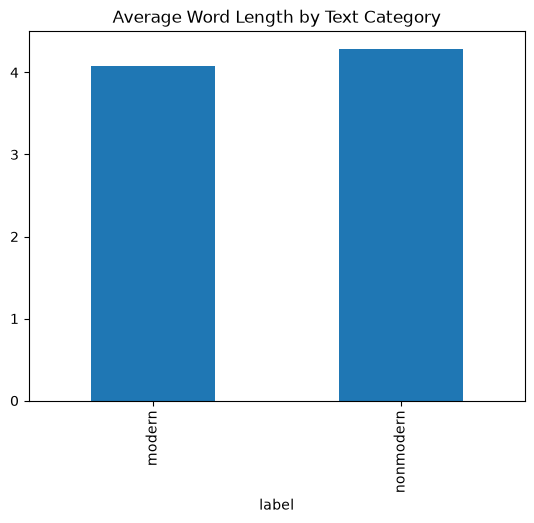

In [122]:
character_df.groupby("label")["average_word_length"].mean().plot(
    kind="bar",
    title="Average Word Length by Text Category"
)

This graph compares the average word length of modern and nonmodern text chunks. Average word length is a simple lexical feature that may capture differences in vocabulary use, although it may also be influenced by author and genre.

<Axes: title={'center': 'Average Punctuation Ratio by Text Category'}, xlabel='label'>

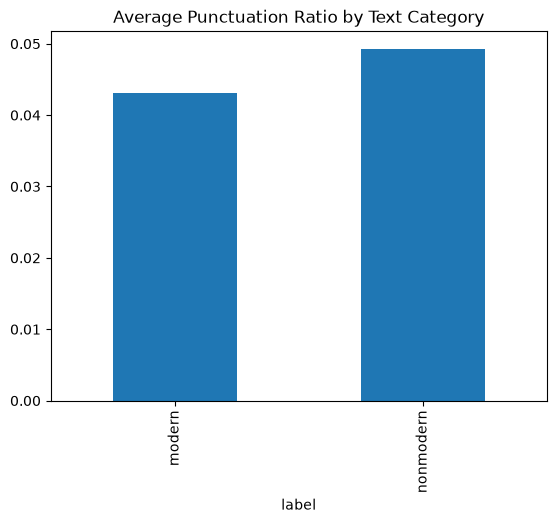

In [123]:
character_df.groupby("label")["punctuation_ratio"].mean().plot(
    kind="bar",
    title="Average Punctuation Ratio by Text Category"
)

This graph compares the overall density of punctuation characters in the two categories. Punctuation density may capture differences in sentence construction, dialogue, interruption, or rhythm, but further texts are needed before it can be treated as a reliable modernist feature.

In [124]:
punctuation_columns = [
    "comma_ratio",
    "semicolon_ratio",
    "colon_ratio",
    "question_mark_ratio",
    "exclamation_mark_ratio"
]

character_df.groupby("label")[punctuation_columns].mean()

,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio
label,,,,,
modern,0.013622,0.001082,0.000011,0.000473,0.000870
nonmodern,0.014383,0.000617,0.000192,0.000845,0.000534


<Axes: title={'center': 'Punctuation Features by Text Category'}>

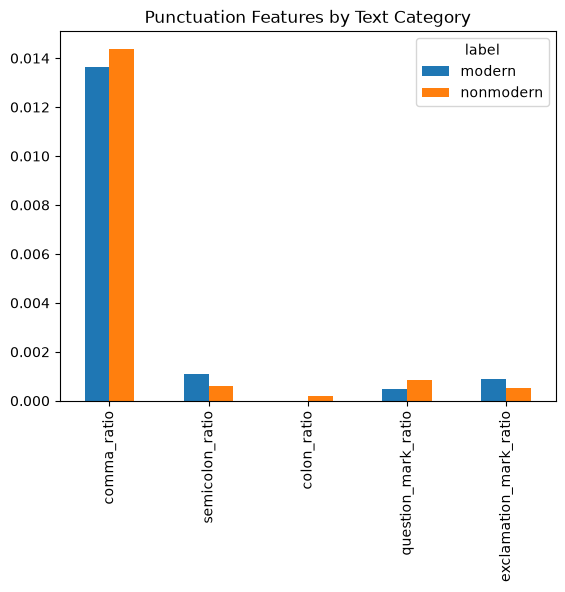

In [125]:
character_df.groupby("label")[punctuation_columns].mean().T.plot(
    kind="bar",
    title="Punctuation Features by Text Category"
)

In [126]:
def get_non_ascii_characters(text):
    return sorted(
        set(
            char for char in text
            if ord(char) > 127
        )
    )

In [127]:
modern_non_ascii = get_non_ascii_characters(modern_text_clean)
nonmodern_non_ascii = get_non_ascii_characters(nonmodern_text_clean)

print("Modern non-ASCII characters:")
print(modern_non_ascii)

print()

print("Nonmodern non-ASCII characters:")
print(nonmodern_non_ascii)

Modern non-ASCII characters:
[]

Nonmodern non-ASCII characters:
[]


In [128]:
for char in modern_non_ascii:
    print(
        repr(char),
        ord(char),
        char.encode("unicode_escape")
    )

The Unicode inspection identifies non-ASCII characters in the text, such as typographic quotation marks or dashes. These characters may reflect editorial formatting rather than literary style, so they should be examined before being used as classifier features. The analysis nevertheless confirms that the UTF-8 text has been read correctly and that Unicode characters are preserved.

In [129]:
def immediate_repetition_features(token_chunk):
    lowercase_tokens = [
        token.lower()
        for token in token_chunk
        if token.isalpha()
    ]

    repeated_pairs = []

    for index in range(len(lowercase_tokens) - 1):
        current_word = lowercase_tokens[index]
        next_word = lowercase_tokens[index + 1]

        if current_word == next_word:
            repeated_pairs.append(current_word)

    return {
        "immediate_repetition_count": len(repeated_pairs),
        "immediate_repetition_types": len(set(repeated_pairs))
    }

In [130]:
immediate_repetition_features(
    ["No", "no", ",", "I", "cannot", "go"]
)

{'immediate_repetition_count': 1, 'immediate_repetition_types': 1}

In [131]:
immediate_rows = []

for chunk in modern_string_chunks:
    features = immediate_repetition_features(chunk)
    features["label"] = "modern"
    immediate_rows.append(features)

for chunk in nonmodern_string_chunks:
    features = immediate_repetition_features(chunk)
    features["label"] = "nonmodern"
    immediate_rows.append(features)

immediate_df = pd.DataFrame(immediate_rows)

immediate_df.head()

,immediate_repetition_count,immediate_repetition_types,label
0,0,0,modern
1,1,1,modern
2,2,2,modern
3,0,0,modern
4,3,2,modern


In [132]:
immediate_df.groupby("label").mean()

,immediate_repetition_count,immediate_repetition_types
label,,
modern,1.313131,1.171717
nonmodern,0.815789,0.815789


Immediate repetition captures cases in which the same word appears twice in succession, such as “no no” or “very very.” This is different from general frequency because it measures repetition as a local textual event. It may provide a closer computational approximation of repetition as emphasis or insistence.

In [133]:
expanded_style_df = pd.concat(
    [
        character_df.drop(columns=["label"]),
        immediate_df.drop(columns=["label"]),
        character_df["label"]
    ],
    axis=1
)

expanded_style_df.head()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,immediate_repetition_count,immediate_repetition_types,label
0,4.137002,0.034964,0.015193,0.000208,0.0,0.000624,0.000624,0.013774,0.001665,0.0,0,0,modern
1,4.162162,0.037168,0.012874,0.001453,0.0,0.000208,0.000208,0.015393,0.000000,0.0,1,1,modern
2,4.115621,0.050462,0.016534,0.000215,0.0,0.000000,0.000429,0.016652,0.000000,0.0,2,2,modern
3,4.201381,0.028483,0.014241,0.000619,0.0,0.000000,0.000206,0.014563,0.000000,0.0,0,0,modern
4,4.099193,0.031601,0.013098,0.000208,0.0,0.000000,0.000208,0.015031,0.000000,0.0,3,2,modern


In [134]:
expanded_style_df.groupby("label").mean()

,average_word_length,punctuation_ratio,comma_ratio,semicolon_ratio,colon_ratio,question_mark_ratio,exclamation_mark_ratio,uppercase_ratio,digit_ratio,non_ascii_ratio,immediate_repetition_count,immediate_repetition_types
label,,,,,,,,,,,,
modern,4.078845,0.043117,0.013622,0.001082,0.000011,0.000473,0.000870,0.019869,0.000017,0.0,1.313131,1.171717
nonmodern,4.289768,0.049313,0.014383,0.000617,0.000192,0.000845,0.000534,0.034880,0.002011,0.0,0.815789,0.815789


The expanded dataset combines character-level, punctuation-level, Unicode-related, and immediate-repetition features. Each row still represents one equally sized text chunk, while each column provides a numerical description of its style.
This dataset is not yet sufficient to train a reliable modernism classifier because the chunks come from only two complete works. However, the workflow demonstrates how multiple textual levels can be converted into fixed numerical features for future classification.

In [135]:
stein_text = Path("Stein The Making of Americans AU1600671.txt").read_text(
    encoding="utf-8",
    errors="ignore"
)

print(stein_text[:500])


It is hard living down the tempers we are born with. We all begin well, for in our youth there is nothing we are more intolerant of than our own sins writ large in others and we fight them fiercely in ourselves; but we grow old and we see that these our sins are of all sins the really harmless ones to own, nay that they give a charm to any character, and so our struggle with them dies away.




It has always seemed to me a rare privilege, this, of being an American, a real American, one whose t


In [136]:
stein_text_clean = stein_text

In [137]:
stein_tokens = word_tokenize(stein_text_clean)

stein_tokens = [
    word.lower()
    for word in stein_tokens
]

In [138]:
stein_words = [
    word
    for word in stein_tokens
    if word.isalpha()
]

In [139]:
stein_words = [
    word
    for word in stein_words
    if word not in stop_words
]

In [140]:
print("Number of Stein content words:", len(stein_words))
print(stein_words[:50])

Number of Stein content words: 198372
['hard', 'living', 'tempers', 'born', 'begin', 'well', 'youth', 'nothing', 'intolerant', 'sins', 'writ', 'large', 'others', 'fight', 'fiercely', 'grow', 'old', 'see', 'sins', 'sins', 'really', 'harmless', 'ones', 'nay', 'give', 'charm', 'character', 'struggle', 'dies', 'away', 'always', 'seemed', 'rare', 'privilege', 'american', 'real', 'american', 'one', 'whose', 'tradition', 'taken', 'scarcely', 'sixty', 'years', 'create', 'need', 'realise', 'parents', 'remember', 'grandparents']


In [141]:
stein_fdist = FreqDist(stein_words)
stein_positions = get_word_positions(stein_words)

In [142]:
stein_fdist.most_common(30)

[('one', 18213),
 ('living', 8682),
 ('feeling', 4541),
 ('thing', 4000),
 ('always', 3080),
 ('every', 2393),
 ('kind', 2346),
 ('way', 2225),
 ('hersland', 2213),
 ('many', 2180),
 ('completely', 1980),
 ('men', 1965),
 ('really', 1875),
 ('women', 1863),
 ('certain', 1802),
 ('knowing', 1748),
 ('certainly', 1731),
 ('little', 1646),
 ('something', 1601),
 ('saying', 1545),
 ('inside', 1489),
 ('ones', 1423),
 ('know', 1405),
 ('sometimes', 1375),
 ('beginning', 1350),
 ('would', 1143),
 ('young', 1131),
 ('children', 1121),
 ('loving', 1112),
 ('thinking', 1088)]

In [143]:
import statistics
import pandas as pd

In [144]:
def text_repetition_features(words, positions, min_occurrences=5):
    repeated_word_counts = []
    all_distances = []

    for word, pos in positions.items():
        if len(pos) >= min_occurrences:
            repeated_word_counts.append(len(pos))
            all_distances.extend(repetition_distances(pos))

    total_words = len(words)
    unique_words = len(set(words))

    return {
        "total_words": total_words,
        "unique_words": unique_words,
        "type_token_ratio": unique_words / total_words,
        "repeated_vocabulary_size": len(repeated_word_counts),
        "mean_frequency_repeated_words": statistics.mean(repeated_word_counts),
        "median_repetition_distance": statistics.median(all_distances),
        "mean_repetition_distance": statistics.mean(all_distances)
    }

In [145]:
stein_features = text_repetition_features(
    stein_words,
    stein_positions
)

nonmodern_features = text_repetition_features(
    nonmodern_words,
    nonmodern_positions
)

comparison_df = pd.DataFrame(
    [stein_features, nonmodern_features],
    index=["Stein", "Nonmodern"]
)

comparison_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,198372,5133,0.025876,1869,103.153023,24.0,1119.471743
Nonmodern,14630,4537,0.310116,624,13.519231,305.0,821.724014


In [146]:
comparison_length = min(
    len(stein_words),
    len(nonmodern_words)
)

stein_sample_words = stein_words[:comparison_length]
nonmodern_sample_words = nonmodern_words[:comparison_length]

stein_sample_positions = get_word_positions(stein_sample_words)
nonmodern_sample_positions = get_word_positions(nonmodern_sample_words)

In [147]:
stein_sample_features = text_repetition_features(
    stein_sample_words,
    stein_sample_positions
)

nonmodern_sample_features = text_repetition_features(
    nonmodern_sample_words,
    nonmodern_sample_positions
)

fair_comparison_df = pd.DataFrame(
    [stein_sample_features, nonmodern_sample_features],
    index=["Stein", "Nonmodern"]
)

fair_comparison_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,14630,2176,0.148735,540,22.120370,77.0,433.147216
Nonmodern,14630,4537,0.310116,624,13.519231,305.0,821.724014


In [148]:
common_words = []

for word in set(stein_sample_words) & set(nonmodern_sample_words):
    stein_count = stein_sample_positions[word]
    nonmodern_count = nonmodern_sample_positions[word]

    if len(stein_count) >= 10 and len(nonmodern_count) >= 10:
        common_words.append(
            (
                word,
                len(stein_count),
                len(nonmodern_count)
            )
        )

common_words.sort(
    key=lambda item: item[1] + item[2],
    reverse=True
)

common_words[:20]

[('always', 317, 20),
 ('one', 206, 115),
 ('said', 38, 257),
 ('children', 259, 14),
 ('would', 160, 80),
 ('could', 153, 65),
 ('living', 189, 11),
 ('little', 165, 34),
 ('way', 174, 23),
 ('man', 116, 62),
 ('well', 95, 80),
 ('never', 137, 37),
 ('good', 118, 46),
 ('like', 102, 48),
 ('know', 102, 48),
 ('made', 105, 45),
 ('make', 98, 43),
 ('new', 87, 46),
 ('things', 110, 19),
 ('old', 94, 31)]

In [149]:
def word_repetition_row(word, positions):
    pos = positions[word]
    distances = repetition_distances(pos)

    return {
        "word": word,
        "occurrences": len(pos),
        "frequency_per_1000": len(pos) / comparison_length * 1000,
        "mean_distance": statistics.mean(distances),
        "median_distance": statistics.median(distances)
    }

In [150]:
rows = []

for word, _, _ in common_words[:15]:
    stein_row = word_repetition_row(
        word,
        stein_sample_positions
    )
    stein_row["text"] = "Stein"

    nonmodern_row = word_repetition_row(
        word,
        nonmodern_sample_positions
    )
    nonmodern_row["text"] = "Nonmodern"

    rows.append(stein_row)
    rows.append(nonmodern_row)

common_word_comparison_df = pd.DataFrame(rows)

common_word_comparison_df[
    [
        "text",
        "word",
        "occurrences",
        "frequency_per_1000",
        "mean_distance",
        "median_distance"
    ]
]

,text,word,occurrences,frequency_per_1000,mean_distance,median_distance
0,Stein,always,317,21.667806,46.186709,24.0
1,Nonmodern,always,20,1.367054,738.684211,393.0
2,Stein,one,206,14.080656,71.009756,25.0
3,Nonmodern,one,115,7.860560,124.219298,76.0
4,Stein,said,38,2.597403,346.729730,110.0
5,Nonmodern,said,257,17.566644,56.332031,37.0
6,Stein,children,259,17.703349,55.670543,22.0
7,Nonmodern,children,14,0.956938,999.230769,371.0
8,Stein,would,160,10.936432,89.610063,25.0
9,Nonmodern,would,80,5.468216,173.683544,112.0


## Text-Level Repetition Feature Extraction

The previous analysis compared individual words shared by Stein and the nonmodern text. The following analysis moves from selected words to text-level repetition features. To make the comparison fair, both texts are represented by samples of the same length.

In [151]:
def build_repetition_table(words, positions, min_occurrences=10):
    rows = []

    for word, pos in positions.items():
        occurrences = len(pos)

        if occurrences < min_occurrences:
            continue

        distances = repetition_distances(pos)

        if len(distances) == 0:
            continue

        mean_distance = statistics.mean(distances)
        median_distance = statistics.median(distances)

        if len(distances) > 1:
            standard_deviation = statistics.stdev(distances)
        else:
            standard_deviation = 0

        if mean_distance > 0:
            distance_cv = standard_deviation / mean_distance
        else:
            distance_cv = 0

        short_gap_ratio_50 = sum(
            distance <= 50
            for distance in distances
        ) / len(distances)

        rows.append({
            "word": word,
            "occurrences": occurrences,
            "frequency_per_1000": occurrences / len(words) * 1000,
            "mean_distance": mean_distance,
            "median_distance": median_distance,
            "distance_standard_deviation": standard_deviation,
            "distance_cv": distance_cv,
            "short_gap_ratio_50": short_gap_ratio_50
        })

    return pd.DataFrame(rows)

In [152]:
stein_word_stats = build_repetition_table(
    stein_sample_words,
    stein_sample_positions,
    min_occurrences=10
)

nonmodern_word_stats = build_repetition_table(
    nonmodern_sample_words,
    nonmodern_sample_positions,
    min_occurrences=10
)

In [153]:
stein_word_stats.head(10)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
0,hard,45,3.075871,322.613636,150.0,452.844509,1.403674,0.340909
1,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213
2,born,16,1.093643,943.200000,489.0,1012.819205,1.073812,0.133333
3,begin,14,0.956938,1124.076923,769.0,976.615539,0.868816,0.000000
4,well,95,6.493506,136.563830,47.5,181.112901,1.326214,0.510638
5,nothing,29,1.982228,491.678571,199.0,723.268151,1.471018,0.285714
6,large,11,0.751880,1164.300000,369.0,1427.102040,1.225717,0.200000
7,others,23,1.572112,641.409091,326.5,745.681450,1.162568,0.136364
8,old,94,6.425154,155.526882,37.0,294.553664,1.893908,0.569892
9,see,45,3.075871,308.045455,117.0,478.630457,1.553766,0.409091


In [154]:
nonmodern_word_stats.head(10)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
0,chapter,13,0.888585,1130.916667,1148.0,316.015667,0.279433,0.000000
1,corsica,14,0.956938,921.307692,114.0,2283.014469,2.478015,0.307692
2,brienne,14,0.956938,692.615385,67.0,1786.025921,2.578669,0.384615
3,napoleon,213,14.559125,68.971698,38.0,84.743713,1.228674,0.617925
4,bonaparte,181,12.371839,80.844444,57.0,85.276666,1.054824,0.455556
5,children,14,0.956938,999.230769,371.0,1010.647907,1.011426,0.153846
6,man,62,4.237867,235.983607,128.0,241.608602,1.023836,0.262295
7,became,15,1.025290,817.714286,584.5,790.088352,0.966216,0.214286
8,emperor,74,5.058100,199.315068,60.0,438.685564,2.200965,0.438356
9,french,43,2.939166,346.333333,202.0,436.284348,1.259724,0.095238


In [155]:
stein_word_stats.sort_values(
    by="frequency_per_1000",
    ascending=False
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
14,always,317,21.667806,46.186709,24.0,52.234210,1.130936,0.702532
43,children,259,17.703349,55.670543,22.0,171.705396,3.084313,0.767442
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
16,one,206,14.080656,71.009756,25.0,120.230946,1.693161,0.653659
1,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213
72,way,174,11.893370,82.046243,52.0,96.937694,1.181501,0.479769
30,little,165,11.278195,87.128049,30.5,148.344573,1.702604,0.628049
58,would,160,10.936432,89.610063,25.0,153.687292,1.715067,0.635220
71,could,153,10.457963,89.736842,44.0,125.203767,1.395233,0.526316
38,inside,144,9.842789,101.412587,29.0,229.329867,2.261355,0.699301


In [156]:
nonmodern_word_stats.sort_values(
    by="frequency_per_1000",
    ascending=False
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
46,said,257,17.566644,56.332031,37.0,53.032982,0.941436,0.589844
3,napoleon,213,14.559125,68.971698,38.0,84.743713,1.228674,0.617925
4,bonaparte,181,12.371839,80.844444,57.0,85.276666,1.054824,0.455556
86,one,115,7.860560,124.219298,76.0,137.672354,1.108301,0.412281
22,would,80,5.468216,173.683544,112.0,175.453737,1.010192,0.265823
80,well,80,5.468216,169.417722,139.0,141.561675,0.835578,0.189873
8,emperor,74,5.058100,199.315068,60.0,438.685564,2.200965,0.438356
169,fouche,74,5.058100,181.205479,31.0,866.739804,4.783188,0.671233
156,paris,73,4.989747,183.597222,138.0,202.214895,1.101405,0.305556
16,joseph,69,4.716336,214.294118,37.0,380.497869,1.775587,0.544118


The tables above show the words occurring at least ten times in each equal-length text sample. Frequency is normalized per 1,000 content words so that the values can be compared directly across texts.

In [157]:
stein_word_stats.sort_values(
    by="median_distance",
    ascending=True
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
272,tired,16,1.093643,9.466667,6.0,12.094076,1.277543,0.933333
282,shilling,19,1.298701,94.333333,6.5,276.011296,2.925915,0.777778
51,us,91,6.220096,160.444444,7.0,491.388153,3.062669,0.788889
195,washing,21,1.435407,68.600000,9.0,235.624009,3.434752,0.950000
250,papa,19,1.298701,350.388889,10.5,975.896941,2.785182,0.611111
261,dying,13,0.888585,561.666667,11.0,1773.442125,3.157464,0.750000
268,religion,70,4.784689,87.985507,13.0,378.801768,4.305275,0.797101
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
242,singularity,11,0.751880,634.200000,16.0,1904.353947,3.002766,0.700000
171,george,20,1.367054,297.052632,19.0,581.005878,1.955902,0.578947


In [158]:
stein_word_stats.sort_values(
    by="median_distance",
    ascending=True
).head(20)

,word,occurrences,frequency_per_1000,mean_distance,median_distance,distance_standard_deviation,distance_cv,short_gap_ratio_50
272,tired,16,1.093643,9.466667,6.0,12.094076,1.277543,0.933333
282,shilling,19,1.298701,94.333333,6.5,276.011296,2.925915,0.777778
51,us,91,6.220096,160.444444,7.0,491.388153,3.062669,0.788889
195,washing,21,1.435407,68.600000,9.0,235.624009,3.434752,0.950000
250,papa,19,1.298701,350.388889,10.5,975.896941,2.785182,0.611111
261,dying,13,0.888585,561.666667,11.0,1773.442125,3.157464,0.750000
268,religion,70,4.784689,87.985507,13.0,378.801768,4.305275,0.797101
86,feeling,225,15.379357,63.986607,14.0,140.490540,2.195624,0.772321
242,singularity,11,0.751880,634.200000,16.0,1904.353947,3.002766,0.700000
171,george,20,1.367054,297.052632,19.0,581.005878,1.955902,0.578947


In [159]:
def summarize_repetition_table(word_stats):
    return {
        "eligible_word_types": len(word_stats),

        "median_frequency_per_1000": word_stats[
            "frequency_per_1000"
        ].median(),

        "median_of_mean_distances": word_stats[
            "mean_distance"
        ].median(),

        "median_of_median_distances": word_stats[
            "median_distance"
        ].median(),

        "median_short_gap_ratio_50": word_stats[
            "short_gap_ratio_50"
        ].median(),

        "median_distance_cv": word_stats[
            "distance_cv"
        ].median()
    }

In [160]:
stein_repetition_summary = summarize_repetition_table(
    stein_word_stats
)

nonmodern_repetition_summary = summarize_repetition_table(
    nonmodern_word_stats
)

In [161]:
text_level_comparison_df = pd.DataFrame(
    [
        stein_repetition_summary,
        nonmodern_repetition_summary
    ],
    index=[
        "Stein",
        "Nonmodern"
    ]
)

text_level_comparison_df

,eligible_word_types,median_frequency_per_1000,median_of_mean_distances,median_of_median_distances,median_short_gap_ratio_50,median_distance_cv
Stein,283,1.367054,496.857143,150.5,0.342105,1.491299
Nonmodern,239,1.093643,737.705882,438.5,0.153846,1.059996


### Text-Level Feature Definitions
-**eligible_word_types**: The number of word types occurring at least ten times in the equal-length sample.

-**median_frequency_per_1000**: The median normalized frequency of the eligible words.

-**median_of_mean_distances**: The median of the mean repetition distances calculated for all eligible words.

-**median_of_median_distances**: The median of the median repetition distances calculated for all eligible words.

-**median_short_gap_ratio_50**: The median proportion of repetitions occurring within fifty content words.

-**median_distance_cv**: The median coefficient of variation of repetition distances. This measures how unevenly or intermittently words recur.

In [162]:
shared_word_stats = pd.merge(
    stein_word_stats,
    nonmodern_word_stats,
    on="word",
    suffixes=("_stein", "_nonmodern")
)

print(
    "Number of shared words appearing at least 10 times in both texts:",
    len(shared_word_stats)
)

shared_word_stats.head()

Number of shared words appearing at least 10 times in both texts: 110


,word,occurrences_stein,frequency_per_1000_stein,mean_distance_stein,median_distance_stein,distance_standard_deviation_stein,distance_cv_stein,short_gap_ratio_50_stein,occurrences_nonmodern,frequency_per_1000_nonmodern,mean_distance_nonmodern,median_distance_nonmodern,distance_standard_deviation_nonmodern,distance_cv_nonmodern,short_gap_ratio_50_nonmodern
0,living,189,12.918660,77.739362,25.0,165.168626,2.124646,0.670213,11,0.751880,1086.300000,955.5,909.237538,0.837004,0.100000
1,well,95,6.493506,136.563830,47.5,181.112901,1.326214,0.510638,80,5.468216,169.417722,139.0,141.561675,0.835578,0.189873
2,nothing,29,1.982228,491.678571,199.0,723.268151,1.471018,0.285714,19,1.298701,699.944444,526.5,758.853739,1.084163,0.055556
3,old,94,6.425154,155.526882,37.0,294.553664,1.893908,0.569892,31,2.118934,476.733333,323.0,602.591125,1.264000,0.266667
4,see,45,3.075871,308.045455,117.0,478.630457,1.553766,0.409091,40,2.734108,354.333333,246.0,383.804112,1.083172,0.256410


In [163]:
shared_word_stats[
    "frequency_difference"
] = (
    shared_word_stats["frequency_per_1000_stein"]
    - shared_word_stats["frequency_per_1000_nonmodern"]
)

shared_word_stats[
    "median_distance_difference"
] = (
    shared_word_stats["median_distance_nonmodern"]
    - shared_word_stats["median_distance_stein"]
)

shared_word_stats[
    "short_gap_ratio_difference"
] = (
    shared_word_stats["short_gap_ratio_50_stein"]
    - shared_word_stats["short_gap_ratio_50_nonmodern"]
)

In [164]:
shared_word_stats[
    [
        "word",
        "occurrences_stein",
        "occurrences_nonmodern",
        "frequency_per_1000_stein",
        "frequency_per_1000_nonmodern",
        "median_distance_stein",
        "median_distance_nonmodern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_nonmodern",
        "median_distance_difference"
    ]
].sort_values(
    by="median_distance_difference",
    ascending=False
).head(20)

,word,occurrences_stein,occurrences_nonmodern,frequency_per_1000_stein,frequency_per_1000_nonmodern,median_distance_stein,median_distance_nonmodern,short_gap_ratio_50_stein,short_gap_ratio_50_nonmodern,median_distance_difference
98,whole,11,11,0.751880,0.751880,168.0,1582.5,0.200000,0.000000,1414.5
33,woman,59,14,4.032809,0.956938,115.5,1053.0,0.379310,0.076923,937.5
0,living,189,11,12.918660,0.751880,25.0,955.5,0.670213,0.100000,930.5
90,business,20,10,1.367054,0.683527,350.0,1227.0,0.263158,0.111111,877.0
24,young,94,11,6.425154,0.751880,54.0,923.0,0.483871,0.000000,869.0
97,three,32,17,2.187286,1.161996,69.0,767.0,0.387097,0.000000,698.0
8,real,30,11,2.050581,0.751880,219.0,866.0,0.172414,0.200000,647.0
109,keep,26,15,1.777170,1.025290,74.0,693.5,0.440000,0.142857,619.5
87,best,12,11,0.820232,0.751880,320.0,849.0,0.090909,0.000000,529.0
91,better,18,14,1.230349,0.956938,155.0,663.0,0.294118,0.000000,508.0


In [165]:
shared_word_stats[
    [
        "word",
        "occurrences_stein",
        "occurrences_nonmodern",
        "frequency_per_1000_stein",
        "frequency_per_1000_nonmodern",
        "median_distance_stein",
        "median_distance_nonmodern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_nonmodern",
        "median_distance_difference"
    ]
].sort_values(
    by="median_distance_difference",
    ascending=True
).head(20)

,word,occurrences_stein,occurrences_nonmodern,frequency_per_1000_stein,frequency_per_1000_nonmodern,median_distance_stein,median_distance_nonmodern,short_gap_ratio_50_stein,short_gap_ratio_50_nonmodern,median_distance_difference
99,two,11,35,0.751880,2.392344,1021.5,287.0,0.000000,0.117647,-734.5
106,course,10,12,0.683527,0.820232,1412.0,730.0,0.222222,0.000000,-682.0
56,friends,11,12,0.751880,0.820232,878.5,211.0,0.000000,0.272727,-667.5
95,city,10,14,0.683527,0.956938,712.0,302.0,0.333333,0.153846,-410.0
100,take,14,30,0.956938,2.050581,555.0,241.0,0.000000,0.068966,-314.0
35,rest,10,15,0.683527,1.025290,718.0,474.0,0.333333,0.142857,-244.0
5,give,23,30,1.572112,2.050581,549.0,359.0,0.090909,0.103448,-190.0
104,began,15,17,1.025290,1.161996,556.5,367.0,0.142857,0.187500,-189.5
62,without,16,20,1.093643,1.367054,551.0,366.0,0.200000,0.157895,-185.0
71,boy,10,12,0.683527,0.820232,491.0,329.0,0.333333,0.181818,-162.0


In [166]:
shared_words_summary_df = pd.DataFrame({
    "Stein": {
        "shared_word_count": len(shared_word_stats),

        "median_frequency_per_1000": shared_word_stats[
            "frequency_per_1000_stein"
        ].median(),

        "median_repetition_distance": shared_word_stats[
            "median_distance_stein"
        ].median(),

        "median_short_gap_ratio_50": shared_word_stats[
            "short_gap_ratio_50_stein"
        ].median(),

        "median_distance_cv": shared_word_stats[
            "distance_cv_stein"
        ].median()
    },

    "Nonmodern": {
        "shared_word_count": len(shared_word_stats),

        "median_frequency_per_1000": shared_word_stats[
            "frequency_per_1000_nonmodern"
        ].median(),

        "median_repetition_distance": shared_word_stats[
            "median_distance_nonmodern"
        ].median(),

        "median_short_gap_ratio_50": shared_word_stats[
            "short_gap_ratio_50_nonmodern"
        ].median(),

        "median_distance_cv": shared_word_stats[
            "distance_cv_nonmodern"
        ].median()
    }
}).T

shared_words_summary_df

,shared_word_count,median_frequency_per_1000,median_repetition_distance,median_short_gap_ratio_50,median_distance_cv
Stein,110.0,2.016405,165.0,0.340580,1.400645
Nonmodern,110.0,1.435407,366.5,0.142857,1.040991


In [167]:
stein_shorter_count = (
    shared_word_stats["median_distance_stein"]
    <
    shared_word_stats["median_distance_nonmodern"]
).sum()

nonmodern_shorter_count = (
    shared_word_stats["median_distance_nonmodern"]
    <
    shared_word_stats["median_distance_stein"]
).sum()

equal_distance_count = (
    shared_word_stats["median_distance_stein"]
    ==
    shared_word_stats["median_distance_nonmodern"]
).sum()

print(
    "Words with shorter median repetition distance in Stein:",
    stein_shorter_count
)

print(
    "Words with shorter median repetition distance in Nonmodern:",
    nonmodern_shorter_count
)

print(
    "Words with equal median repetition distance:",
    equal_distance_count
)

Words with shorter median repetition distance in Stein: 88
Words with shorter median repetition distance in Nonmodern: 22
Words with equal median repetition distance: 0


In [168]:
stein_shorter_percentage = (
    stein_shorter_count
    / len(shared_word_stats)
    * 100
)

nonmodern_shorter_percentage = (
    nonmodern_shorter_count
    / len(shared_word_stats)
    * 100
)

print(
    "Percentage of shared words repeating sooner in Stein:",
    round(stein_shorter_percentage, 2),
    "%"
)

print(
    "Percentage of shared words repeating sooner in Nonmodern:",
    round(nonmodern_shorter_percentage, 2),
    "%"
)

Percentage of shared words repeating sooner in Stein: 80.0 %
Percentage of shared words repeating sooner in Nonmodern: 20.0 %


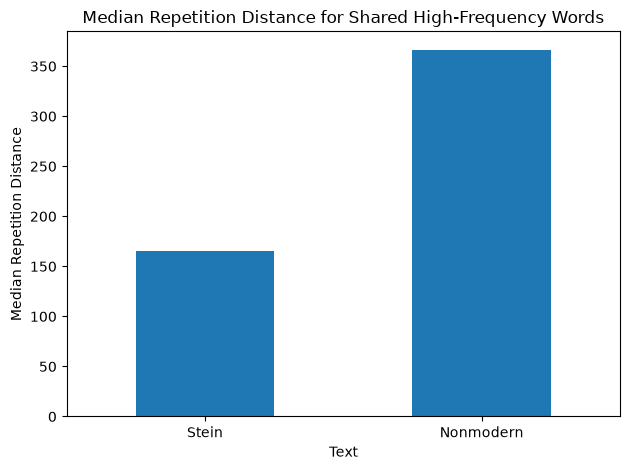

In [169]:
distance_plot_data = shared_words_summary_df[
    ["median_repetition_distance"]
]

distance_plot_data.plot(
    kind="bar",
    legend=False
)

plt.title(
    "Median Repetition Distance for Shared High-Frequency Words"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A lower median repetition distance indicates that high-frequency words tend to recur sooner in the text.

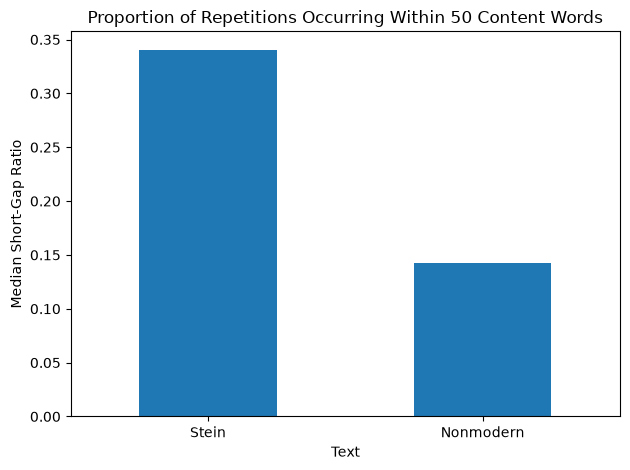

In [170]:
short_gap_plot_data = shared_words_summary_df[
    ["median_short_gap_ratio_50"]
]

short_gap_plot_data.plot(
    kind="bar",
    legend=False
)

plt.title(
    "Proportion of Repetitions Occurring Within 50 Content Words"
)

plt.xlabel("Text")
plt.ylabel("Median Short-Gap Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

A higher short-gap ratio indicates that a larger proportion of repetitions occur within fifty content words.

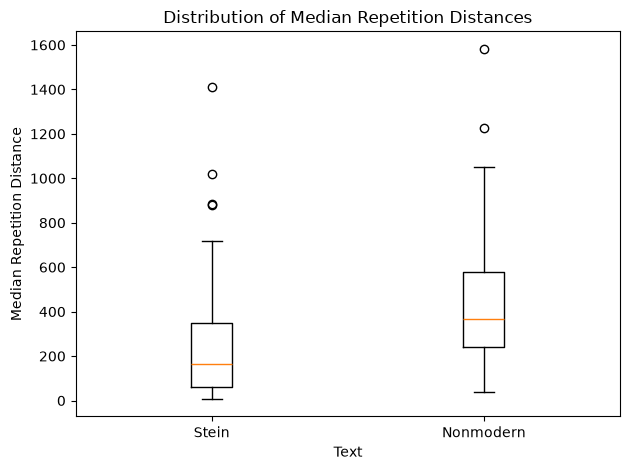

In [171]:
plt.boxplot(
    [
        shared_word_stats["median_distance_stein"],
        shared_word_stats["median_distance_nonmodern"]
    ],
    tick_labels=[
        "Stein",
        "Nonmodern"
    ]
)

plt.title(
    "Distribution of Median Repetition Distances"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.tight_layout()
plt.show()

In [172]:
stein_shared_median_distance = shared_words_summary_df.loc[
    "Stein",
    "median_repetition_distance"
]

nonmodern_shared_median_distance = shared_words_summary_df.loc[
    "Nonmodern",
    "median_repetition_distance"
]

stein_shared_short_gap = shared_words_summary_df.loc[
    "Stein",
    "median_short_gap_ratio_50"
]

nonmodern_shared_short_gap = shared_words_summary_df.loc[
    "Nonmodern",
    "median_short_gap_ratio_50"
]

print("RESULT SUMMARY")
print()

print(
    "The analysis compared",
    len(shared_word_stats),
    "word types that appeared at least ten times in both equal-length text samples."
)

print()

print(
    "The median repetition distance was",
    round(stein_shared_median_distance, 2),
    "for Stein and",
    round(nonmodern_shared_median_distance, 2),
    "for the nonmodern text."
)

print()

print(
    "The median short-gap ratio was",
    round(stein_shared_short_gap, 3),
    "for Stein and",
    round(nonmodern_shared_short_gap, 3),
    "for the nonmodern text."
)

print()

print(
    round(stein_shorter_percentage, 2),
    "% of the shared high-frequency words repeated sooner in Stein."
)

RESULT SUMMARY

The analysis compared 110 word types that appeared at least ten times in both equal-length text samples.

The median repetition distance was 165.0 for Stein and 366.5 for the nonmodern text.

The median short-gap ratio was 0.341 for Stein and 0.143 for the nonmodern text.

80.0 % of the shared high-frequency words repeated sooner in Stein.


## Preliminary Interpretation

The comparison used equal-length samples from *The Making of Americans* and the nonmodern text. Only words appearing at least ten times in both samples were included in the shared-vocabulary analysis. This reduced the influence of unequal text length and prevented the comparison from depending entirely on words unique to one text.

Among the shared high-frequency words, number percent had a shorter median repetition distance in Stein. The median repetition distance across the shared words was stein value in Stein and nonmodern value in the nonmodern text. Stein also had a higher/lower median short-gap ratio, indicating that a larger/smaller proportion of its repetitions occurred within fifty content words.

Several words, including *always*, *children*, and *living*, occurred substantially more frequently and at shorter intervals in Stein. However, this pattern did not apply to every word. For example, *said* was more frequent and repeated at shorter intervals in the nonmodern text. This suggests that the distinction is not simply that Stein repeats every word more frequently. Instead, the two texts may emphasize different kinds of repeated vocabulary and different patterns of recurrence.

These results shows that normalized frequency, median repetition distance, short-gap repetition ratio, and variation in repetition distance may be useful features for distinguishing textual styles. However, this comparison includes only one Stein text and one nonmodern text, so the observed differences cannot yet be treated as general characteristics of modernism.

# Stein and Ordinary Modernist Fiction Comparison

The previous section compared Gertrude Stein's *The Making of Americans* with one nonmodernist text. That comparison suggested that Stein's repeated vocabulary often returned at shorter intervals.

However, this result does not yet show whether Stein differs specifically from nonmodernist writing or whether the pattern is common across modernist fiction.

In this section, I compare Stein with one text from the ordinary modernist-fiction corpus. I use the same preprocessing, equal-length sampling, shared-vocabulary threshold, and repetition measurements used in the previous comparison.

In [173]:
print("Stein total content words:", len(stein_words))
print("Ordinary modernist total content words:", len(modern_words))

Stein total content words: 198372
Ordinary modernist total content words: 37783


In [174]:
stein_modern_comparison_length = min(
    len(stein_words),
    len(modern_words)
)

stein_modern_sample_words = stein_words[
    :stein_modern_comparison_length
]

ordinary_modern_sample_words = modern_words[
    :stein_modern_comparison_length
]

print(
    "Comparison length:",
    stein_modern_comparison_length
)

print(
    "Stein sample length:",
    len(stein_modern_sample_words)
)

print(
    "Ordinary modernist sample length:",
    len(ordinary_modern_sample_words)
)

Comparison length: 37783
Stein sample length: 37783
Ordinary modernist sample length: 37783


## Equal-Length Sampling

The complete Stein text is substantially longer than the selected ordinary modernist text. Directly comparing the complete works would make frequency and repetition measurements difficult to interpret.

I therefore truncate both texts to the length of the shorter text. The comparison uses the same number of cleaned content words from Stein and the ordinary modernist text.

In [176]:
stein_modern_sample_positions = get_word_positions(
    stein_modern_sample_words
)

ordinary_modern_sample_positions = get_word_positions(
    ordinary_modern_sample_words
)

In [178]:
print(
    "Number of word types in Stein:",
    len(stein_modern_sample_positions)
)

print(
    "Number of word types in ordinary modernist text:",
    len(ordinary_modern_sample_positions)
)

Number of word types in Stein: 2642
Number of word types in ordinary modernist text: 5983


In [179]:
print("Positions of 'always' in Stein:")

print(
    stein_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

print()

print("Positions of 'always' in ordinary modernist text:")

print(
    ordinary_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

Positions of 'always' in Stein:
[30, 111, 158, 164, 176, 288, 293, 300, 332, 343, 462, 473, 533, 551, 600, 617, 677, 680, 686, 689]

Positions of 'always' in ordinary modernist text:
[1170, 2050, 2217, 2261, 3393, 3856, 3864, 6361, 6441, 6970, 7843, 8044, 8274, 9403, 9823, 9856, 9876, 10079, 11416, 11451]


In [180]:
print("Positions of 'always' in Stein:")

print(
    stein_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

print()

print("Positions of 'always' in ordinary modernist text:")

print(
    ordinary_modern_sample_positions.get(
        "always",
        []
    )[:20]
)

Positions of 'always' in Stein:
[30, 111, 158, 164, 176, 288, 293, 300, 332, 343, 462, 473, 533, 551, 600, 617, 677, 680, 686, 689]

Positions of 'always' in ordinary modernist text:
[1170, 2050, 2217, 2261, 3393, 3856, 3864, 6361, 6441, 6970, 7843, 8044, 8274, 9403, 9823, 9856, 9876, 10079, 11416, 11451]


In [182]:
stein_modern_sample_fdist = FreqDist(
    stein_modern_sample_words
)

ordinary_modern_sample_fdist = FreqDist(
    ordinary_modern_sample_words
)

## Word Positions and Frequency Distributions

For each equal-length sample, I created a dictionary recording every position at which each content word appears. These position lists will be used to calculate the distances between consecutive occurrences of the same word.

I also created frequency distributions for both samples. These distributions show how often each word appears and allow the analysis to identify vocabulary that occurs frequently in both Stein and the ordinary modernist text.

In [183]:
stein_ordinary_modern_features = text_repetition_features(
    stein_modern_sample_words,
    stein_modern_sample_positions
)

ordinary_modern_features = text_repetition_features(
    ordinary_modern_sample_words,
    ordinary_modern_sample_positions
)

In [184]:
stein_vs_ordinary_modern_df = pd.DataFrame(
    [
        stein_ordinary_modern_features,
        ordinary_modern_features
    ],
    index=[
        "Stein",
        "Ordinary Modernist"
    ]
)

stein_vs_ordinary_modern_df

,total_words,unique_words,type_token_ratio,repeated_vocabulary_size,mean_frequency_repeated_words,median_repetition_distance,mean_repetition_distance
Stein,37783,2642,0.069926,828,41.992754,50.0,577.322403
Ordinary Modernist,37783,5983,0.158352,1476,20.544715,396.0,1419.290037


## Overall Text-Level Repetition Features

The table provides a broad comparison of repetition in the two equal-length samples.

The type-token ratio measures lexical diversity by dividing the number of unique words by the total number of words. A lower value indicates that the text repeatedly draws from a smaller vocabulary.

Repeated vocabulary size counts the number of word types that meet the minimum repetition threshold. Median repetition distance measures the typical number of content words between consecutive occurrences of repeated words. A lower median distance indicates that repeated vocabulary tends to return more quickly.

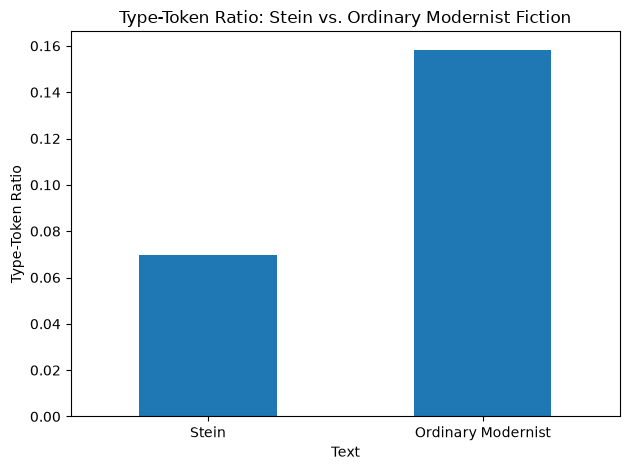

In [186]:
stein_vs_ordinary_modern_df[
    "type_token_ratio"
].plot(
    kind="bar",
    title="Type-Token Ratio: Stein vs. Ordinary Modernist Fiction"
)

plt.xlabel("Text")
plt.ylabel("Type-Token Ratio")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

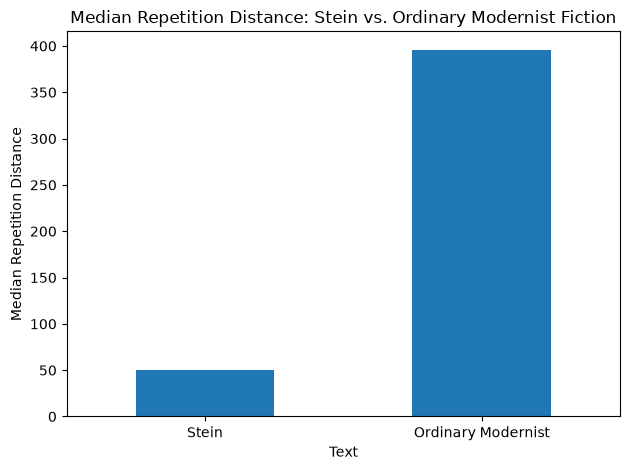

In [187]:
stein_vs_ordinary_modern_df[
    "median_repetition_distance"
].plot(
    kind="bar",
    title="Median Repetition Distance: Stein vs. Ordinary Modernist Fiction"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Shared High-Frequency Vocabulary

The overall text-level measurements include vocabulary that may be unique to a particular work, such as character names and topic-specific terms.

To create a more controlled comparison, I next retain only words that appear at least ten times in both equal-length samples. This allows the analysis to compare how the same frequently occurring words behave in Stein and in ordinary modernist fiction.

In [188]:
minimum_shared_frequency = 10

stein_ordinary_shared_words = sorted(
    [
        word
        for word in stein_modern_sample_fdist
        if (
            stein_modern_sample_fdist[word]
            >= minimum_shared_frequency
            and
            ordinary_modern_sample_fdist[word]
            >= minimum_shared_frequency
        )
    ]
)

print(
    "Number of shared high-frequency words:",
    len(stein_ordinary_shared_words)
)

print()

print("First 50 shared words:")

print(
    stein_ordinary_shared_words[:50]
)

Number of shared high-frequency words: 251

First 50 shared words:
['afraid', 'age', 'almost', 'alone', 'already', 'always', 'among', 'another', 'asked', 'away', 'back', 'bear', 'beauty', 'began', 'behind', 'believe', 'best', 'better', 'big', 'body', 'born', 'boy', 'break', 'bright', 'broke', 'brought', 'came', 'certain', 'change', 'child', 'children', 'choose', 'clear', 'close', 'come', 'comes', 'coming', 'common', 'could', 'country', 'cut', 'daughter', 'day', 'days', 'dead', 'died', 'dogs', 'done', 'early', 'either']


In [191]:
def shared_word_repetition_features(
    word,
    words,
    positions,
    short_gap_threshold=50
):
    word_positions = positions[word]

    distances = repetition_distances(
        word_positions
    )

    frequency = len(word_positions)

    frequency_per_1000 = (
        frequency / len(words)
    ) * 1000

    if len(distances) == 0:
        median_distance = np.nan
        mean_distance = np.nan
        distance_std = np.nan
        short_gap_ratio = np.nan
        distance_cv = np.nan

    else:
        median_distance = statistics.median(
            distances
        )

        mean_distance = statistics.mean(
            distances
        )

        if len(distances) >= 2:
            distance_std = statistics.stdev(
                distances
            )
        else:
            distance_std = 0

        short_gap_count = sum(
            distance <= short_gap_threshold
            for distance in distances
        )

        short_gap_ratio = (
            short_gap_count / len(distances)
        )

        if mean_distance != 0:
            distance_cv = (
                distance_std / mean_distance
            )
        else:
            distance_cv = np.nan

    return {
        "frequency": frequency,
        "frequency_per_1000": frequency_per_1000,
        "median_distance": median_distance,
        "mean_distance": mean_distance,
        "distance_std": distance_std,
        "short_gap_ratio_50": short_gap_ratio,
        "distance_cv": distance_cv
    }

In [192]:
test_word = stein_ordinary_shared_words[0]

print("Test word:", test_word)

print()

print("Stein:")
print(
    shared_word_repetition_features(
        test_word,
        stein_modern_sample_words,
        stein_modern_sample_positions
    )
)

print()

print("Ordinary modernist:")
print(
    shared_word_repetition_features(
        test_word,
        ordinary_modern_sample_words,
        ordinary_modern_sample_positions
    )
)

Test word: afraid

Stein:
{'frequency': 26, 'frequency_per_1000': 0.6881401688590107, 'median_distance': 12, 'mean_distance': 1006.72, 'distance_std': 1969.723870664786, 'short_gap_ratio_50': 0.56, 'distance_cv': 1.9565756820812004}

Ordinary modernist:
{'frequency': 19, 'frequency_per_1000': 0.5028716618585077, 'median_distance': 1052.5, 'mean_distance': 1525.611111111111, 'distance_std': 1543.109585483305, 'short_gap_ratio_50': 0.1111111111111111, 'distance_cv': 1.011469813142256}


In [193]:
stein_ordinary_shared_rows = []

for word in stein_ordinary_shared_words:
    stein_word_features = (
        shared_word_repetition_features(
            word,
            stein_modern_sample_words,
            stein_modern_sample_positions
        )
    )

    ordinary_modern_word_features = (
        shared_word_repetition_features(
            word,
            ordinary_modern_sample_words,
            ordinary_modern_sample_positions
        )
    )

    row = {
        "word": word,

        "frequency_stein":
            stein_word_features["frequency"],

        "frequency_ordinary_modern":
            ordinary_modern_word_features[
                "frequency"
            ],

        "frequency_per_1000_stein":
            stein_word_features[
                "frequency_per_1000"
            ],

        "frequency_per_1000_ordinary_modern":
            ordinary_modern_word_features[
                "frequency_per_1000"
            ],

        "median_distance_stein":
            stein_word_features[
                "median_distance"
            ],

        "median_distance_ordinary_modern":
            ordinary_modern_word_features[
                "median_distance"
            ],

        "short_gap_ratio_50_stein":
            stein_word_features[
                "short_gap_ratio_50"
            ],

        "short_gap_ratio_50_ordinary_modern":
            ordinary_modern_word_features[
                "short_gap_ratio_50"
            ],

        "distance_cv_stein":
            stein_word_features[
                "distance_cv"
            ],

        "distance_cv_ordinary_modern":
            ordinary_modern_word_features[
                "distance_cv"
            ]
    }

    stein_ordinary_shared_rows.append(row)

In [195]:
stein_ordinary_shared_df = pd.DataFrame(
    stein_ordinary_shared_rows
)

stein_ordinary_shared_df.head(20)

,word,frequency_stein,frequency_ordinary_modern,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern,distance_cv_stein,distance_cv_ordinary_modern
0,afraid,26,19,0.688140,0.502872,12.0,1052.5,0.560000,0.111111,1.956576,1.011470
1,age,15,15,0.397004,0.397004,1333.0,503.0,0.285714,0.000000,1.053586,1.801001
2,almost,99,64,2.620226,1.693883,133.5,308.0,0.367347,0.079365,1.366741,1.030272
3,alone,17,44,0.449938,1.164545,569.5,687.0,0.375000,0.116279,1.309855,0.868037
4,already,21,10,0.555806,0.264669,794.5,2666.0,0.100000,0.111111,1.228475,0.827585
5,always,791,49,20.935341,1.296880,22.0,441.5,0.710127,0.125000,1.417664,0.990292
6,among,32,62,0.846942,1.640950,425.0,358.0,0.290323,0.147541,1.356683,1.034253
7,another,48,42,1.270413,1.111611,175.0,637.0,0.276596,0.121951,1.800072,0.968239
8,asked,13,24,0.344070,0.635206,751.0,982.0,0.250000,0.043478,1.261329,1.183610
9,away,147,82,3.890639,2.170288,52.0,239.0,0.479452,0.197531,2.040301,1.108272


In [196]:
stein_ordinary_shared_df[
    "frequency_difference"
] = (
    stein_ordinary_shared_df[
        "frequency_per_1000_stein"
    ]
    -
    stein_ordinary_shared_df[
        "frequency_per_1000_ordinary_modern"
    ]
)

stein_ordinary_shared_df[
    "median_distance_difference"
] = (
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
    -
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
)

stein_ordinary_shared_df[
    "short_gap_ratio_difference"
] = (
    stein_ordinary_shared_df[
        "short_gap_ratio_50_stein"
    ]
    -
    stein_ordinary_shared_df[
        "short_gap_ratio_50_ordinary_modern"
    ]
)

stein_ordinary_shared_df.head()

,word,frequency_stein,frequency_ordinary_modern,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern,distance_cv_stein,distance_cv_ordinary_modern,frequency_difference,median_distance_difference,short_gap_ratio_difference
0,afraid,26,19,0.688140,0.502872,12.0,1052.5,0.560000,0.111111,1.956576,1.011470,0.185269,1040.5,0.448889
1,age,15,15,0.397004,0.397004,1333.0,503.0,0.285714,0.000000,1.053586,1.801001,0.000000,-830.0,0.285714
2,almost,99,64,2.620226,1.693883,133.5,308.0,0.367347,0.079365,1.366741,1.030272,0.926343,174.5,0.287982
3,alone,17,44,0.449938,1.164545,569.5,687.0,0.375000,0.116279,1.309855,0.868037,-0.714607,117.5,0.258721
4,already,21,10,0.555806,0.264669,794.5,2666.0,0.100000,0.111111,1.228475,0.827585,0.291136,1871.5,-0.011111


In [197]:
stein_ordinary_shared_df.sort_values(
    by="median_distance_difference",
    ascending=False
)[
    [
        "word",
        "frequency_per_1000_stein",
        "frequency_per_1000_ordinary_modern",
        "median_distance_stein",
        "median_distance_ordinary_modern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_ordinary_modern"
    ]
].head(20)

,word,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern
212,thin,0.264669,0.264669,118.0,3385.0,0.444444,0.000000
125,lose,0.635206,0.264669,273.0,3284.0,0.304348,0.111111
174,remember,0.476405,0.264669,166.0,3130.0,0.470588,0.000000
87,half,1.032210,0.317603,3.5,2774.0,0.842105,0.181818
196,stayed,0.264669,0.291136,54.0,2680.5,0.444444,0.000000
231,weakness,1.243946,0.370537,58.5,2597.0,0.478261,0.076923
119,living,26.784533,0.344070,14.0,2268.0,0.818002,0.000000
105,large,0.423471,0.344070,633.0,2862.5,0.200000,0.000000
153,nothing,2.620226,0.397004,58.5,2200.5,0.479592,0.142857
40,cut,0.608739,0.317603,377.5,2497.0,0.318182,0.000000


In [198]:
stein_ordinary_shared_df.sort_values(
    by="median_distance_difference",
    ascending=True
)[
    [
        "word",
        "frequency_per_1000_stein",
        "frequency_per_1000_ordinary_modern",
        "median_distance_stein",
        "median_distance_ordinary_modern",
        "short_gap_ratio_50_stein",
        "short_gap_ratio_50_ordinary_modern"
    ]
].head(20)

,word,frequency_per_1000_stein,frequency_per_1000_ordinary_modern,median_distance_stein,median_distance_ordinary_modern,short_gap_ratio_50_stein,short_gap_ratio_50_ordinary_modern
44,dead,0.291136,0.873409,1896.5,271.0,0.300000,0.218750
169,pretty,0.264669,0.529339,1820.0,438.0,0.000000,0.052632
198,strange,0.344070,2.170288,1651.0,287.0,0.333333,0.234568
96,joy,0.317603,1.005743,1491.0,184.0,0.090909,0.162162
172,quite,0.264669,0.397004,2161.0,865.0,0.111111,0.142857
205,sweet,0.317603,0.767541,1549.0,331.0,0.181818,0.142857
25,brought,0.397004,0.767541,1816.5,599.0,0.142857,0.071429
50,else,0.423471,0.661673,1921.0,756.0,0.133333,0.125000
103,known,0.291136,1.217479,1548.0,410.0,0.000000,0.088889
141,might,0.582272,3.573035,1291.0,178.0,0.142857,0.320896


In [199]:
stein_ordinary_shared_summary_df = pd.DataFrame(
    {
        "shared_word_count": [
            len(stein_ordinary_shared_df),
            len(stein_ordinary_shared_df)
        ],

        "median_frequency_per_1000": [
            stein_ordinary_shared_df[
                "frequency_per_1000_stein"
            ].median(),

            stein_ordinary_shared_df[
                "frequency_per_1000_ordinary_modern"
            ].median()
        ],

        "median_repetition_distance": [
            stein_ordinary_shared_df[
                "median_distance_stein"
            ].median(),

            stein_ordinary_shared_df[
                "median_distance_ordinary_modern"
            ].median()
        ],

        "median_short_gap_ratio_50": [
            stein_ordinary_shared_df[
                "short_gap_ratio_50_stein"
            ].median(),

            stein_ordinary_shared_df[
                "short_gap_ratio_50_ordinary_modern"
            ].median()
        ],

        "median_distance_cv": [
            stein_ordinary_shared_df[
                "distance_cv_stein"
            ].median(),

            stein_ordinary_shared_df[
                "distance_cv_ordinary_modern"
            ].median()
        ]
    },
    index=[
        "Stein",
        "Ordinary Modernist"
    ]
)

stein_ordinary_shared_summary_df

,shared_word_count,median_frequency_per_1000,median_repetition_distance,median_short_gap_ratio_50,median_distance_cv
Stein,251,0.952809,183.0,0.333333,1.739687
Ordinary Modernist,251,0.846942,592.0,0.117647,1.151580


In [200]:
stein_shorter_word_count = (
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
    <
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
).sum()

ordinary_modern_shorter_word_count = (
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
    <
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
).sum()

equal_distance_word_count = (
    stein_ordinary_shared_df[
        "median_distance_stein"
    ]
    ==
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ]
).sum()

stein_shorter_percentage = (
    stein_shorter_word_count
    /
    len(stein_ordinary_shared_df)
) * 100

print(
    "Words repeating sooner in Stein:",
    stein_shorter_word_count
)

print(
    "Words repeating sooner in ordinary modernist fiction:",
    ordinary_modern_shorter_word_count
)

print(
    "Words with equal median repetition distance:",
    equal_distance_word_count
)

print(
    "Percentage repeating sooner in Stein:",
    round(stein_shorter_percentage, 2),
    "%"
)

Words repeating sooner in Stein: 198
Words repeating sooner in ordinary modernist fiction: 53
Words with equal median repetition distance: 0
Percentage repeating sooner in Stein: 78.88 %


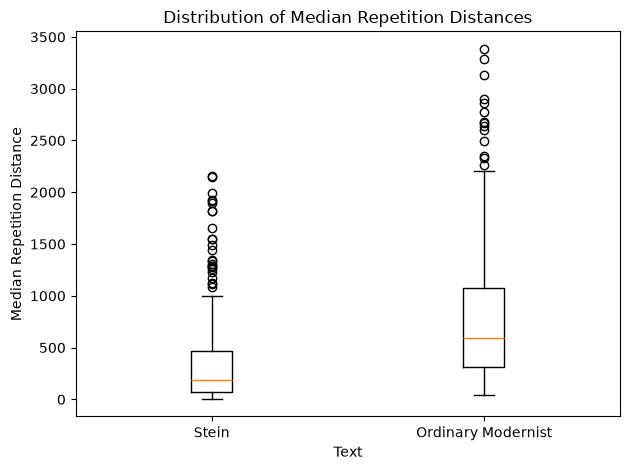

In [201]:
plt.boxplot(
    [
        stein_ordinary_shared_df[
            "median_distance_stein"
        ].dropna(),

        stein_ordinary_shared_df[
            "median_distance_ordinary_modern"
        ].dropna()
    ],
    tick_labels=[
        "Stein",
        "Ordinary Modernist"
    ]
)

plt.title(
    "Distribution of Median Repetition Distances"
)

plt.xlabel("Text")
plt.ylabel("Median Repetition Distance")
plt.tight_layout()
plt.show()

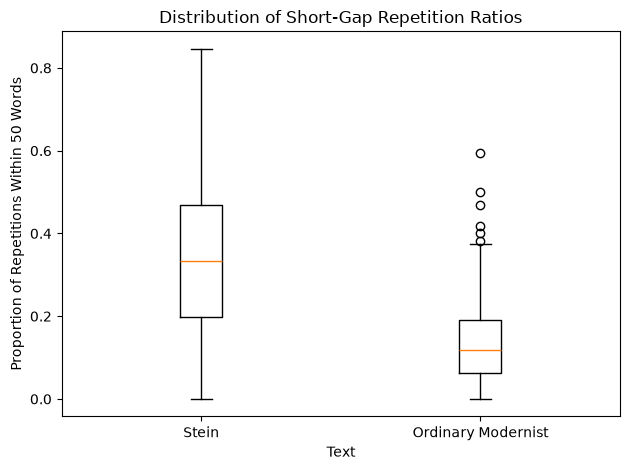

In [202]:
plt.boxplot(
    [
        stein_ordinary_shared_df[
            "short_gap_ratio_50_stein"
        ].dropna(),

        stein_ordinary_shared_df[
            "short_gap_ratio_50_ordinary_modern"
        ].dropna()
    ],
    tick_labels=[
        "Stein",
        "Ordinary Modernist"
    ]
)

plt.title(
    "Distribution of Short-Gap Repetition Ratios"
)

plt.xlabel("Text")
plt.ylabel(
    "Proportion of Repetitions Within 50 Words"
)

plt.tight_layout()
plt.show()

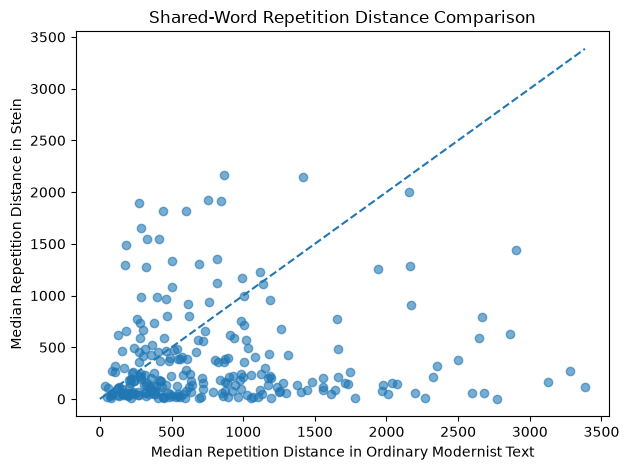

In [203]:
plt.scatter(
    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ],
    stein_ordinary_shared_df[
        "median_distance_stein"
    ],
    alpha=0.6
)

maximum_distance = max(
    stein_ordinary_shared_df[
        "median_distance_stein"
    ].max(),

    stein_ordinary_shared_df[
        "median_distance_ordinary_modern"
    ].max()
)

plt.plot(
    [0, maximum_distance],
    [0, maximum_distance],
    linestyle="--"
)

plt.xlabel(
    "Median Repetition Distance in Ordinary Modernist Text"
)

plt.ylabel(
    "Median Repetition Distance in Stein"
)

plt.title(
    "Shared-Word Repetition Distance Comparison"
)

plt.tight_layout()
plt.show()

In [204]:
stein_shared_median_distance_modern = (
    stein_ordinary_shared_summary_df.loc[
        "Stein",
        "median_repetition_distance"
    ]
)

ordinary_modern_shared_median_distance = (
    stein_ordinary_shared_summary_df.loc[
        "Ordinary Modernist",
        "median_repetition_distance"
    ]
)

stein_shared_short_gap_modern = (
    stein_ordinary_shared_summary_df.loc[
        "Stein",
        "median_short_gap_ratio_50"
    ]
)

ordinary_modern_shared_short_gap = (
    stein_ordinary_shared_summary_df.loc[
        "Ordinary Modernist",
        "median_short_gap_ratio_50"
    ]
)

print("RESULT SUMMARY")
print()

print(
    "The analysis compared",
    len(stein_ordinary_shared_df),
    "word types that appeared at least ten times",
    "in both equal-length text samples."
)

print()

print(
    "The median repetition distance was",
    round(
        stein_shared_median_distance_modern,
        2
    ),
    "for Stein and",
    round(
        ordinary_modern_shared_median_distance,
        2
    ),
    "for the ordinary modernist text."
)

print()

print(
    "The median short-gap ratio was",
    round(
        stein_shared_short_gap_modern,
        3
    ),
    "for Stein and",
    round(
        ordinary_modern_shared_short_gap,
        3
    ),
    "for the ordinary modernist text."
)

print()

print(
    round(stein_shorter_percentage, 2),
    "% of the shared high-frequency words",
    "repeated sooner in Stein."
)

RESULT SUMMARY

The analysis compared 251 word types that appeared at least ten times in both equal-length text samples.

The median repetition distance was 183.0 for Stein and 592.0 for the ordinary modernist text.

The median short-gap ratio was 0.333 for Stein and 0.118 for the ordinary modernist text.

78.88 % of the shared high-frequency words repeated sooner in Stein.


## Preliminary Interpretation

The comparison used equal-length samples from Gertrude Stein's *The Making of Americans* and one text from the ordinary modernist-fiction corpus. Only words appearing at least ten times in both samples were included in the shared-vocabulary analysis. This reduced the influence of unequal text length and excluded vocabulary unique to only one work.

The analysis identified 251 shared high-frequency word types. Among these shared words, 78.88% showed a shorter median repetition distance in Stein than in the ordinary modernist text. The median repetition distance was 183 content words in Stein compared with 592 content words in the ordinary modernist sample. Similarly, the median short-gap ratio was 0.333 in Stein but only 0.118 in the ordinary modernist text, indicating that repeated words returned much more frequently within short spans.

These findings suggest that Stein's repetitive style is not simply representative of modernist fiction in general. Even when compared with another modernist work using equal-length samples and shared vocabulary, Stein consistently reused the same words more quickly and more locally. This supports the hypothesis that Stein's characteristic repetition represents an unusually strong stylistic tendency rather than merely a common feature of literary modernism.

Nevertheless, this comparison includes only one Stein text and one ordinary modernist text. Differences may also reflect author, genre, narrative structure, or thematic vocabulary. Additional texts from the larger corpus will therefore be needed before drawing broader conclusions about modernist writing as a whole.